# Proyecto: Predicción logística en E-commerce Brasil (Olist)
Este notebook construye el dataset para un modelo predictivo sobre la operación logística de un marketplace brasileño (dataset público de Olist).

# Flujo general del notebook:

1. Carga de los datasets originales (clientes, pedidos, productos, vendedores, pagos, geolocalización) desde Google Drive.

2. Cálculo de la distancia (Haversine) entre cada vendedor y su cliente, a partir de las coordenadas de geolocalización.

3. Construcción de un dataframe a nivel de pedido (final_df / df_clean) con variables de fechas, entregas, pagos y productos.

4. Creación de features temporales tipo "lag" a nivel diario (T-1, T-2, promedio móvil de 7 días y mes anterior) para variables como transacciones, facturación, peso, volumen, días de entrega y distancia. Estas variables 
representan el "estado de la red logística" en días anteriores a cada compra, evitando fuga de información (data leakage) hacia el futuro.

5. Validaciones cruzadas manuales para confirmar que los lags (T-1, T-2, 7D, mes anterior) están correctamente calculados y alineados por fecha.

6. Limpieza final, manejo de nulos y exportación del dataset (df_distancia) listo para modelado.

# Mauricio Blanco

# **Conexión a Google Drive y carga de datasets**

In [ ]:
import pandas as pd
from google.colab import drive
import numpy as np
from typing import cast

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

ruta = '/content/drive/MyDrive/Colab Notebooks/Maestria ciencias de datos/Data mining/Proyecto/Datos/brazilian e-commerce/'

customers = pd.read_csv(ruta + 'olist_customers_dataset.csv')
geolocation = pd.read_csv(ruta + 'olist_geolocation_dataset.csv')
order_items = pd.read_csv(ruta + 'olist_order_items_dataset.csv')
payments = pd.read_csv(ruta + 'olist_order_payments_dataset.csv')
# reviews = pd.read_csv(ruta + 'olist_order_reviews_dataset.csv')
orders = pd.read_csv(ruta + 'olist_orders_dataset.csv')
products = pd.read_csv(ruta + 'olist_products_dataset.csv')
sellers = pd.read_csv(ruta + 'olist_sellers_dataset.csv')
category_translation = pd.read_csv(ruta + 'product_category_name_translation.csv')

# **Cálculo de distancia (Haversine), geolocalización y manejo de distancias**

In [ ]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

In [ ]:
geo_agg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

In [ ]:
customers_zip = customers[['customer_id', 'customer_zip_code_prefix']]

# Todos los ítems del pedido (no solo el más caro), con su vendedor
items_con_sellers = order_items.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id', how='left')

# Traer el customer_id desde orders, y el zip code del cliente
items_con_sellers = items_con_sellers.merge(orders[['order_id', 'customer_id']], on='order_id', how='left')
items_con_sellers = items_con_sellers.merge(customers_zip, on='customer_id', how='left')

print(items_con_sellers.shape)
items_con_sellers.head()

(112650, 10)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,customer_id,customer_zip_code_prefix
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,3ce436f183e68e07877b285a838db11a,28013
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,f6dd3ec061db4e3987629fe6b26e5cce,15775
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,6489ae5e4333f3693df5ad4372dab6d3,35661
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,d4eb9395c8c0431ee92fce09860c5a06,12952
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,58dbd0b2d70206bf40e62cd34e84d795,13226


In [ ]:
items_con_sellers = items_con_sellers.merge(
    geo_agg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
                             'lat': 'customer_lat', 'lng': 'customer_lng'}),
    on='customer_zip_code_prefix', how='left'
)

items_con_sellers = items_con_sellers.merge(
    geo_agg.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
                             'lat': 'seller_lat', 'lng': 'seller_lng'}),
    on='seller_zip_code_prefix', how='left'
)

In [ ]:
items_con_sellers['distancia_item_km'] = haversine(
    items_con_sellers['customer_lat'], items_con_sellers['customer_lng'],
    items_con_sellers['seller_lat'], items_con_sellers['seller_lng']
)

print(items_con_sellers[['order_id', 'seller_id', 'distancia_item_km']].head())

                           order_id                         seller_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  48436dade18ac8b2bce089ec2a041202   
1  00018f77f2f0320c557190d7a144bdd3  dd7ddc04e1b6c2c614352b383efe2d36   
2  000229ec398224ef6ca0657da4fc703e  5b51032eddd242adc84c38acab88f23d   
3  00024acbcdf0a6daa1e931b038114c75  9d7a1d34a5052409006425275ba1c2b4   
4  00042b26cf59d7ce69dfabb4e55b4fd9  df560393f3a51e74553ab94004ba5c87   

   distancia_item_km  
0         301.504681  
1         585.563937  
2         312.343511  
3         293.168420  
4         646.163463  


In [ ]:
item_principal = items_con_sellers.sort_values('distancia_item_km', ascending=False).drop_duplicates('order_id')
item_principal_zip = item_principal[['order_id', 'seller_zip_code_prefix']]

print(item_principal_zip.shape)
item_principal_zip.head()

(98666, 2)


,order_id,seller_zip_code_prefix
60915,8ad3f1d0f96992e43566c4c82c9f6c58,89288
75917,acdbc7396e191931c263db11af241d62,14110
34191,4d5abe7999d76d1fb6237d3677706af0,14110
60328,897ec6416d50126a9061626f0fc2d658,5849
34929,4f1583d080fe1eec5e509335d79b17c6,8710


In [ ]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
# 1. Sumar el total pagado y contar la cantidad de registros de pago por orden
payments_agg = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    payment_count=('payment_type', 'count')
).reset_index()

# 2. Extraer el medio de pago principal (el de mayor valor) usando idxmax
idx_max = payments.groupby('order_id')['payment_value'].idxmax()
principal_payments = payments.loc[idx_max, ['order_id', 'payment_type']].rename(columns={'payment_type': 'principal_payment_type'})

# 3. Consolidar en un único dataframe de pagos con una fila por order_id
payments_processed = pd.merge(payments_agg, principal_payments, on='order_id', how='left')

In [ ]:
print("order_items:", order_items.columns)
print("\nsellers:", sellers.columns)
print("\nproducts:", products.columns)


order_items: Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

sellers: Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')

products: Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')


# **Integración y agregación de características por pedido**

In [ ]:
# 1. Cruzar order_items con sellers (solo ID y estado)
items_sellers = pd.merge(
    order_items,
    sellers[['seller_id', 'seller_state']],
    on='seller_id',
    how='left'
)

# 2. Cruzar con products (incluyendo categoría, peso y dimensiones para el volumen)
product_cols = [
    'product_id', 'product_category_name',
    'product_weight_g', 'product_length_cm',
    'product_height_cm', 'product_width_cm'
]
items_sellers_products = pd.merge(
    items_sellers,
    products[product_cols],
    on='product_id',
    how='left'
)

# 3. Calcular el volumen de cada producto individual en metros cúbicos (m3)
# Las dimensiones están en cm, por lo que dividimos entre 1,000,000 para pasar a cm3 a m3
items_sellers_products['product_volume_mc3'] = (
    items_sellers_products['product_length_cm'] *
    items_sellers_products['product_height_cm'] *
    items_sellers_products['product_width_cm']
)

# 4. Agregaciones principales por orden (order_id)
items_agg = items_sellers_products.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    total_weight_g=('product_weight_g', 'sum'),
    total_volume_cm3=('product_volume_mc3', 'sum'),
    seller_state_count=('seller_state', 'nunique'),
    category_count=('product_category_name', 'nunique')
).reset_index()


# 5. Extraer categoría principal y estado del seller principal
# a) Basado en el artículo más costoso (price)
idx_max_price = items_sellers_products.groupby('order_id')['price'].idxmax()
principal_by_price = items_sellers_products.loc[idx_max_price.dropna(), ['order_id', 'product_category_name', 'seller_state']].rename(columns={
    'product_category_name': 'principal_category_by_price',
    'seller_state': 'principal_seller_state_by_price'
})

# b) Basado en el artículo más pesado (weight)
idx_max_weight = items_sellers_products.groupby('order_id')['product_weight_g'].idxmax()
principal_by_weight = items_sellers_products.loc[idx_max_weight.dropna(), ['order_id', 'product_category_name', 'seller_state']].rename(columns={
    'product_category_name': 'principal_category_by_weight',
    'seller_state': 'principal_seller_state_by_weight'
})

# c) Basado en el artículo de mayor volumen (volume)
# Nota: dejé product_volume_mc3 tal como lo escribiste, asegúrate de que coincida con el paso 3
idx_max_volume = items_sellers_products.groupby('order_id')['product_volume_mc3'].idxmax()
principal_by_volume = items_sellers_products.loc[idx_max_volume.dropna(), ['order_id', 'product_category_name', 'seller_state']].rename(columns={
    'product_category_name': 'principal_category_by_volume',
    'seller_state': 'principal_seller_state_by_volume'
})

# 6. Consolidar en un único dataframe de items por orden
items_processed = pd.merge(items_agg, principal_by_price, on='order_id', how='left')
items_processed = pd.merge(items_processed, principal_by_weight, on='order_id', how='left')
items_processed = pd.merge(items_processed, principal_by_volume, on='order_id', how='left')

In [ ]:
items_processed.columns

Index(['order_id', 'total_price', 'total_freight', 'total_weight_g',
       'total_volume_cm3', 'seller_state_count', 'category_count',
       'principal_category_by_price', 'principal_seller_state_by_price',
       'principal_category_by_weight', 'principal_seller_state_by_weight',
       'principal_category_by_volume', 'principal_seller_state_by_volume'],
      dtype='object')

In [ ]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [ ]:
# 1. Copiar orders asegurando los tipos de fecha (timestamp)
orders_processed = orders.copy()

timestamp_cols = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in timestamp_cols:
    orders_processed[col] = pd.to_datetime(orders_processed[col])

# 2. Verificación de unicidad por order_id en orders
print(f"Total de filas en orders: {len(orders_processed)}")
print(f"Total de order_id únicos: {orders_processed['order_id'].nunique()}")

Total de filas en orders: 99441
Total de order_id únicos: 99441


# **Consolidación del dataframe final y validación**

In [ ]:
# 1. Seleccionar columnas deseadas de customers y cruzar con orders_processed
customer_cols = ['customer_id', 'customer_unique_id', 'customer_state']
orders_with_customers = pd.merge(
    orders_processed,
    customers[customer_cols],
    on='customer_id',
    how='left'
)

# 2. Unir con los pagos procesados
final_df = pd.merge(
    orders_with_customers,
    payments_processed,
    on='order_id',
    how='left'
)

# 3. Unir con los items, sellers y productos procesados
final_df = pd.merge(
    final_df,
    items_processed,
    on='order_id',
    how='left'
)

# 4. Verificaciones de control de calidad y granularidad
print(f"Total de filas en el dataframe consolidado: {len(final_df)}")
print(f"Total de order_id únicos: {final_df['order_id'].nunique()}")
print(f"¿La granularidad es exactamente 1 fila por transacción?: {len(final_df) == final_df['order_id'].nunique()}")

Total de filas en el dataframe consolidado: 99441
Total de order_id únicos: 99441
¿La granularidad es exactamente 1 fila por transacción?: True


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   order_id                          99441 non-null  object        
 1   customer_id                       99441 non-null  object        
 2   order_status                      99441 non-null  object        
 3   order_purchase_timestamp          99441 non-null  datetime64[ns]
 4   order_approved_at                 99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date      97658 non-null  datetime64[ns]
 6   order_delivered_customer_date     96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date     99441 non-null  datetime64[ns]
 8   customer_unique_id                99441 non-null  object        
 9   customer_state                    99441 non-null  object        
 10  total_payment_value               99440 non-nu

In [ ]:
# Calcular los días de entrega en números enteros de días (sin horas, minutos ni segundos)
final_df['delivery_days'] = (
    final_df['order_delivered_customer_date'] - final_df['order_purchase_timestamp']
).dt.days

# Verificación de la columna resultante
print(final_df[['order_purchase_timestamp', 'order_delivered_customer_date', 'delivery_days']].head())
print(f"Cantidad de órdenes sin fecha de entrega (nulos): {final_df['delivery_days'].isna().sum()}")

  order_purchase_timestamp order_delivered_customer_date  delivery_days
0      2017-10-02 10:56:33           2017-10-10 21:25:13            8.0
1      2018-07-24 20:41:37           2018-08-07 15:27:45           13.0
2      2018-08-08 08:38:49           2018-08-17 18:06:29            9.0
3      2017-11-18 19:28:06           2017-12-02 00:28:42           13.0
4      2018-02-13 21:18:39           2018-02-16 18:17:02            2.0
Cantidad de órdenes sin fecha de entrega (nulos): 2965


In [ ]:
# Extraer componentes de la fecha y hora de compra
final_df['purchase_date'] = final_df['order_purchase_timestamp'].dt.date
final_df['purchase_time'] = final_df['order_purchase_timestamp'].dt.time
final_df['purchase_month'] = final_df['order_purchase_timestamp'].dt.month
final_df['purchase_year'] = final_df['order_purchase_timestamp'].dt.year

# Verificación rápida de las nuevas columnas
print(final_df[['order_purchase_timestamp', 'purchase_date', 'purchase_time', 'purchase_month', 'purchase_year']].head())

  order_purchase_timestamp purchase_date purchase_time  purchase_month  \
0      2017-10-02 10:56:33    2017-10-02      10:56:33              10   
1      2018-07-24 20:41:37    2018-07-24      20:41:37               7   
2      2018-08-08 08:38:49    2018-08-08      08:38:49               8   
3      2017-11-18 19:28:06    2017-11-18      19:28:06              11   
4      2018-02-13 21:18:39    2018-02-13      21:18:39               2   

   purchase_year  
0           2017  
1           2018  
2           2018  
3           2017  
4           2018  


In [ ]:
# Extraer la hora de la compra como un número entero en formato de 24 horas (0 a 23)
final_df['purchase_hour'] = final_df['order_purchase_timestamp'].dt.hour

# Si prefieres que quede estrictamente como un texto de dos cifras (ej. "08", "14"), puedes usar:
# final_df['purchase_hour'] = final_df['order_purchase_timestamp'].dt.strftime('%H')

# Verificación rápida de la nueva columna de hora
print(final_df[['order_purchase_timestamp', 'purchase_hour']].head())

  order_purchase_timestamp  purchase_hour
0      2017-10-02 10:56:33             10
1      2018-07-24 20:41:37             20
2      2018-08-08 08:38:49              8
3      2017-11-18 19:28:06             19
4      2018-02-13 21:18:39             21


In [ ]:
# Extraer componentes de la fecha y hora de entrega
final_df['delivery_date'] = final_df['order_delivered_customer_date'].dt.date
final_df['delivery_day'] = final_df['order_delivered_customer_date'].dt.day
final_df['delivery_hour'] = final_df['order_delivered_customer_date'].dt.hour

# Verificación rápida de las nuevas columnas de entrega
print(final_df[['order_delivered_customer_date', 'delivery_date', 'delivery_day', 'delivery_hour']].head())

  order_delivered_customer_date delivery_date  delivery_day  delivery_hour
0           2017-10-10 21:25:13    2017-10-10          10.0           21.0
1           2018-08-07 15:27:45    2018-08-07           7.0           15.0
2           2018-08-17 18:06:29    2018-08-17          17.0           18.0
3           2017-12-02 00:28:42    2017-12-02           2.0            0.0
4           2018-02-16 18:17:02    2018-02-16          16.0           18.0


In [ ]:
final_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_state', 'total_payment_value',
       'payment_count', 'principal_payment_type', 'total_price',
       'total_freight', 'total_weight_g', 'total_volume_cm3',
       'seller_state_count', 'category_count', 'principal_category_by_price',
       'principal_seller_state_by_price', 'principal_category_by_weight',
       'principal_seller_state_by_weight', 'principal_category_by_volume',
       'principal_seller_state_by_volume', 'delivery_days', 'purchase_date',
       'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour',
       'delivery_date', 'delivery_day', 'delivery_hour'],
      dtype='object')

In [ ]:
df_model = final_df.copy()
# Asegurar que delivery_date esté limpio como fecha (sin horas) y filtrar nulos
df_model['delivery_date'] = pd.to_datetime(df_model['delivery_date']).dt.date

# Crear el nuevo dataset agrupado por día de entrega incluyendo la cantidad de transacciones
daily_summary_df = df_model.dropna(subset=['delivery_date']).groupby('delivery_date').agg(
    # Cantidad de transacciones entregadas ese día
    transacciones_count=('order_id', 'count'),

    # Facturación (usando total_payment_value)
    facturacion_total=('total_payment_value', 'sum'),
    facturacion_promedio=('total_payment_value', 'mean'),
    facturacion_mediana=('total_payment_value', 'median'),
    facturacion_std=('total_payment_value', 'std'),

    # Peso
    peso_total=('total_weight_g', 'sum'),
    peso_promedio=('total_weight_g', 'mean'),
    peso_mediana=('total_weight_g', 'median'),
    peso_std=('total_weight_g', 'std'),

    # Volumen
    volumen_total=('total_volume_cm3', 'sum'),
    volumen_promedio=('total_volume_cm3', 'mean'),
    volumen_mediana=('total_volume_cm3', 'median'),
    volumen_std=('total_volume_cm3', 'std'),

    # Días de entrega
    dias_entrega_total=('delivery_days', 'sum'),
    dias_entrega_promedio=('delivery_days', 'mean'),
    dias_entrega_mediana=('delivery_days', 'median'),
    dias_entrega_std=('delivery_days', 'std')
).reset_index()

# Vista previa del nuevo dataset diario con la cantidad de transacciones
print(daily_summary_df.head())
print(f"Total de días únicos registrados: {len(daily_summary_df)}")

  delivery_date  transacciones_count  facturacion_total  facturacion_promedio  \
0    2016-10-11                    2             212.95            106.475000   
1    2016-10-13                   14            1805.81            128.986429   
2    2016-10-14                   16            3254.53            203.408125   
3    2016-10-15                   17            2897.81            170.459412   
4    2016-10-16                    8            1367.40            170.925000   

   facturacion_mediana  facturacion_std  peso_total  peso_promedio  \
0              106.475         7.120565      4200.0    2100.000000   
1               78.365        98.357510     17317.0    1236.928571   
2              134.695       171.159269     38536.0    2408.500000   
3               92.970       162.460990     45987.0    2705.117647   
4              117.900       130.842541      9085.0    1135.625000   

   peso_mediana     peso_std  volumen_total  volumen_promedio  \
0        2100.0  1272.79220

In [ ]:
max_volume_row = daily_summary_df.loc[daily_summary_df['volumen_total'].idxmax()]

max_volume = max_volume_row['volumen_total']
max_volume_delivery_date = max_volume_row['delivery_date']

print(f"El volumen total máximo registrado fue: {max_volume:.2f} cm3")
print(f"Este volumen fue entregado en la fecha: {max_volume_delivery_date}")

El volumen total máximo registrado fue: 8196019.00 cm3
Este volumen fue entregado en la fecha: 2018-03-28


In [ ]:
daily_summary_df.columns

Index(['delivery_date', 'transacciones_count', 'facturacion_total',
       'facturacion_promedio', 'facturacion_mediana', 'facturacion_std',
       'peso_total', 'peso_promedio', 'peso_mediana', 'peso_std',
       'volumen_total', 'volumen_promedio', 'volumen_mediana', 'volumen_std',
       'dias_entrega_total', 'dias_entrega_promedio', 'dias_entrega_mediana',
       'dias_entrega_std'],
      dtype='object')

In [ ]:
# Crear una copia de trabajo para no afectar el dataframe original
df_clean = final_df.copy()

# 1. Filtrar para mantener estrictamente las órdenes con estado 'delivered'
df_clean = df_clean[df_clean['order_status'] == 'delivered']

# 2. Lista de fechas originales completas a eliminar
fechas_completas = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

# 3. Eliminar las columnas de fechas completas en la nueva copia
df_clean = df_clean.drop(columns=[col for col in fechas_completas if col in df_clean.columns], errors='ignore')

# Verificación de los cambios realizados
print(f"Total de filas después de filtrar solo 'delivered': {len(df_clean)}")
print(f"Columnas restantes: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

Total de filas después de filtrar solo 'delivered': 96478
Columnas restantes: 29
['order_id', 'customer_id', 'order_status', 'customer_unique_id', 'customer_state', 'total_payment_value', 'payment_count', 'principal_payment_type', 'total_price', 'total_freight', 'total_weight_g', 'total_volume_cm3', 'seller_state_count', 'category_count', 'principal_category_by_price', 'principal_seller_state_by_price', 'principal_category_by_weight', 'principal_seller_state_by_weight', 'principal_category_by_volume', 'principal_seller_state_by_volume', 'delivery_days', 'purchase_date', 'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour', 'delivery_date', 'delivery_day', 'delivery_hour']


In [ ]:
daily_summary_df.head()

,delivery_date,transacciones_count,facturacion_total,facturacion_promedio,facturacion_mediana,facturacion_std,peso_total,peso_promedio,peso_mediana,peso_std,volumen_total,volumen_promedio,volumen_mediana,volumen_std,dias_entrega_total,dias_entrega_promedio,dias_entrega_mediana,dias_entrega_std
0,2016-10-11,2,212.95,106.475000,106.475,7.120565,4200.0,2100.000000,2100.0,1272.792206,41750.0,20875.000000,20875.0,11844.038585,14.0,7.000000,7.0,0.000000
1,2016-10-13,14,1805.81,128.986429,78.365,98.357510,17317.0,1236.928571,509.0,1985.140238,167107.0,11936.214286,6550.0,18245.527520,108.0,7.714286,8.0,0.611250
2,2016-10-14,16,3254.53,203.408125,134.695,171.159269,38536.0,2408.500000,1250.0,2684.929397,230790.0,14424.375000,10000.0,15099.897266,114.0,7.125000,7.0,1.147461
3,2016-10-15,17,2897.81,170.459412,92.970,162.460990,45987.0,2705.117647,600.0,5726.877584,340027.0,20001.588235,8000.0,30261.391865,114.0,6.705882,7.0,0.985184
4,2016-10-16,8,1367.40,170.925000,117.900,130.842541,9085.0,1135.625000,455.0,1594.250916,66373.0,8296.625000,5286.0,7179.614612,67.0,8.375000,7.0,1.922610


In [ ]:
# 1. Asegurar formato datetime y ordenar en el dataframe diario
daily_summary_df['delivery_date'] = pd.to_datetime(daily_summary_df['delivery_date'])
daily_summary_df = daily_summary_df.sort_values('delivery_date')

# ==========================================
# PARTE A: T-1 y PROMEDIO MÓVIL 7 DÍAS
# ==========================================
summary_features = daily_summary_df.set_index('delivery_date')

# Calcular el promedio móvil de los últimos 7 días
rolling_7d = summary_features[[
    'transacciones_count', 'facturacion_total', 'peso_total',
    'volumen_total', 'dias_entrega_promedio'
]].rolling(window='7D').mean().add_suffix('_7d_avg')

# Unir el T-1 con el Móvil 7D
summary_features = summary_features.join(rolling_7d).reset_index()

# Crear llave de cruce para T-1: Sumar 1 día a la entrega
summary_features['join_date'] = summary_features['delivery_date'] + pd.Timedelta(days=1)
summary_features['join_date'] = pd.to_datetime(summary_features['join_date']).dt.date

# Renombrar para identificar claramente
summary_features = summary_features.rename(columns={
    'delivery_date': 'estado_red_fecha_origen',
    'dias_entrega_promedio': 'dias_entrega_promedio_t1',
    'transacciones_count': 'transacciones_count_t1',
    'facturacion_total': 'facturacion_total_t1',
    'peso_total': 'peso_total_t1',
    'volumen_total': 'volumen_total_t1'
})

# ==========================================
# PARTE A.2: AGREGAR T-2 (LAG-2)
# ==========================================
summary_t2 = daily_summary_df[[
    'delivery_date', 'dias_entrega_promedio', 'transacciones_count',
    'facturacion_total', 'peso_total', 'volumen_total'
]].copy()

# Sumar 2 días para que coincida con la join_date del pedido
summary_t2['join_date'] = summary_t2['delivery_date'] + pd.Timedelta(days=2)
summary_t2['join_date'] = pd.to_datetime(summary_t2['join_date']).dt.date

summary_t2 = summary_t2.rename(columns={
    'dias_entrega_promedio': 'dias_entrega_promedio_t2',
    'transacciones_count': 'transacciones_count_t2',
    'facturacion_total': 'facturacion_total_t2',
    'peso_total': 'peso_total_t2',
    'volumen_total': 'volumen_total_t2'
}).drop(columns=['delivery_date'])

# Unir el T-2 al summary_features usando la misma join_date
summary_features = pd.merge(summary_features, summary_t2, on='join_date', how='left')

# ==========================================
# PARTE B: MES ANTERIOR COMPLETO
# ==========================================
# Crear una columna de periodo mensual (Año-Mes)
daily_summary_df['delivery_period'] = daily_summary_df['delivery_date'].dt.to_period('M')

# Agrupar por mes para obtener los totales y promedios mensuales
monthly_summary = daily_summary_df.groupby('delivery_period').agg(
    transacciones_count_prev_month=('transacciones_count', 'sum'),
    facturacion_total_prev_month=('facturacion_total', 'sum'),
    peso_total_prev_month=('peso_total', 'sum'),
    volumen_total_prev_month=('volumen_total', 'sum'),
    dias_entrega_promedio_prev_month=('dias_entrega_promedio', 'mean')
).reset_index()

# TRUCO ANTIFUGA: Desplazar 1 mes hacia adelante.
# Lo que pasó en Junio, ahora será la llave de búsqueda para las compras de Julio.
monthly_summary['join_period'] = monthly_summary['delivery_period'] + 1

# Extraer el año y mes de la llave para cruzar fácilmente con df_clean
monthly_summary['join_year'] = monthly_summary['join_period'].dt.year
monthly_summary['join_month'] = monthly_summary['join_period'].dt.month

# Limpieza de columnas temporales en el resumen mensual
monthly_summary = monthly_summary.drop(columns=['delivery_period', 'join_period'])

print("Características de T-1, T-2 y T-7D listas en 'summary_features'.")
print("Características de Mes Anterior listas en 'monthly_summary'.")

Características de T-1, T-2 y T-7D listas en 'summary_features'.
Características de Mes Anterior listas en 'monthly_summary'.


In [ ]:
# 1. Extraer año y mes de la fecha de cruce en summary_features
summary_features['join_year'] = pd.to_datetime(summary_features['join_date']).dt.year
summary_features['join_month'] = pd.to_datetime(summary_features['join_date']).dt.month

# 2. Hacer el merge (Left join para mantener todos los días de summary_features)
master_summary = pd.merge(
    summary_features,
    monthly_summary,
    on=['join_year', 'join_month'],
    how='left'
)

# 3. Eliminar las columnas auxiliares de año y mes, ya que en el df_clean
# tenemos 'purchase_month' y 'purchase_year', pero haremos el cruce exacto por fecha
master_summary = master_summary.drop(columns=['join_year', 'join_month'])

# Verificación de las columnas que quedaron en nuestro resumen maestro
print(f"Total de columnas en la tabla de contexto logístico: {len(master_summary.columns)}")
print("\nVista previa de las llaves temporales y las métricas T-1, 7D y Mes Anterior:")
cols_to_show = [
    'join_date',
    'transacciones_count_t1',
    'transacciones_count_t2',       # <- Agregado para verificar
    'transacciones_count_7d_avg',
    'transacciones_count_prev_month'
]
print(master_summary[cols_to_show].head(15))

Total de columnas en la tabla de contexto logístico: 34

Vista previa de las llaves temporales y las métricas T-1, 7D y Mes Anterior:
     join_date  transacciones_count_t1  transacciones_count_t2  \
0   2016-10-12                       2                     NaN   
1   2016-10-14                      14                     NaN   
2   2016-10-15                      16                    14.0   
3   2016-10-16                      17                    16.0   
4   2016-10-17                       8                    17.0   
5   2016-10-18                      21                     8.0   
6   2016-10-19                      16                    21.0   
7   2016-10-20                       9                    16.0   
8   2016-10-21                      10                     9.0   
9   2016-10-22                       4                    10.0   
10  2016-10-23                       1                     4.0   
11  2016-10-25                      16                     NaN   
12  2016

In [ ]:
# 1. Crear una copia de trabajo a partir de df_clean
df_model_ready = df_clean.copy()

# 2. Asegurar que las fechas en ambos dataframes estén en el mismo formato exacto
df_model_ready['purchase_date'] = pd.to_datetime(df_model_ready['purchase_date']).dt.date
master_summary['join_date'] = pd.to_datetime(master_summary['join_date']).dt.date

# 3. Aplicar el filtro de fecha: desde el 2016-11-01 en adelante
fecha_corte = pd.to_datetime('2016-11-01').date()
df_model_ready = df_model_ready[df_model_ready['purchase_date'] >= fecha_corte]

# 4. Hacer el merge (Left Join para conservar todas las compras que pasaron el filtro)
df_final_model = pd.merge(
    df_model_ready,
    master_summary,
    left_on='purchase_date',
    right_on='join_date',
    how='left'
)

# 5. Limpieza: eliminar 'join_date' porque es completamente redundante con 'purchase_date'
df_final_model = df_final_model.drop(columns=['join_date'], errors='ignore')

# Verificación de resultados
print(f"Total de registros desde Nov-2016: {len(df_final_model)}")
print(f"Total de columnas en el dataset final predictivo: {len(df_final_model.columns)}")
print("\nMuestra de compras con su contexto logístico inyectado:")

cols_muestra = [
    'order_id',
    'purchase_date',
    'transacciones_count_t1',
    'transacciones_count_7d_avg',
    'transacciones_count_prev_month'
]
print(df_final_model[cols_muestra].head())

Total de registros desde Nov-2016: 96212
Total de columnas en el dataset final predictivo: 62

Muestra de compras con su contexto logístico inyectado:
                           order_id purchase_date  transacciones_count_t1  \
0  e481f51cbdc54678b7cc49136f2d6af7    2017-10-02                    39.0   
1  53cdb2fc8bc7dce0b6741e2150273451    2018-07-24                   347.0   
2  47770eb9100c2d0c44946d9cf07ec65d    2018-08-08                   337.0   
3  949d5b44dbf5de918fe9c16f97b45f8a    2017-11-18                   180.0   
4  ad21c59c0840e6cb83a9ceb5573f8159    2018-02-13                     2.0   

   transacciones_count_7d_avg  transacciones_count_prev_month  
0                  137.857143                          3965.0  
1                   93.714286                          6829.0  
2                  236.000000                          5839.0  
3                  121.142857                          4494.0  
4                  157.571429                          6597.0  


In [ ]:
df_final_model.columns

Index(['order_id', 'customer_id', 'order_status', 'customer_unique_id',
       'customer_state', 'total_payment_value', 'payment_count',
       'principal_payment_type', 'total_price', 'total_freight',
       'total_weight_g', 'total_volume_cm3', 'seller_state_count',
       'category_count', 'principal_category_by_price',
       'principal_seller_state_by_price', 'principal_category_by_weight',
       'principal_seller_state_by_weight', 'principal_category_by_volume',
       'principal_seller_state_by_volume', 'delivery_days', 'purchase_date',
       'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour',
       'delivery_date', 'delivery_day', 'delivery_hour',
       'estado_red_fecha_origen', 'transacciones_count_t1',
       'facturacion_total_t1', 'facturacion_promedio', 'facturacion_mediana',
       'facturacion_std', 'peso_total_t1', 'peso_promedio', 'peso_mediana',
       'peso_std', 'volumen_total_t1', 'volumen_promedio', 'volumen_mediana',
       'volumen_std', 'd

In [ ]:
# --- PRUEBA 1: Verificación visual de fechas ---
print("--- 1. MUESTRA VISUAL DE FECHAS ---")
cols_verificacion = ['order_id', 'purchase_date', 'estado_red_fecha_origen', 'transacciones_count_t1', 'transacciones_count_t2']# Tomamos una muestra aleatoria para no ver solo el primer día
print(df_final_model[cols_verificacion].dropna().sample(5))


# --- PRUEBA 2: Validar la regla T-1 matemáticamente ---
print("\n--- 2. VALIDACIÓN MATEMÁTICA (REGLA T-1) ---")
# Convertimos temporalmente a datetime para calcular la diferencia
fechas_compra = pd.to_datetime(df_final_model['purchase_date'])
fechas_origen = pd.to_datetime(df_final_model['estado_red_fecha_origen'])

# Calculamos los días de diferencia
diferencia_dias = (fechas_compra - fechas_origen).dt.days

# Verificamos si absolutamente todos los cruces válidos tienen 1 día de diferencia
es_valido = (diferencia_dias.dropna() == 1).all()
print(f"¿El 100% de las fechas cruzadas tienen exactamente 1 día de diferencia (T-1)?: {'Sí, todo correcto ✅' if es_valido else 'No, hay un error ❌'}")


# --- PRUEBA 3: Verificación Cruzada Manual (Cross-Check) ---
print("\n--- 3. PRUEBA DE FUEGO: VERIFICACIÓN MANUAL ---")
# Escogemos una fecha de compra cualquiera que exista en tus datos (ej. 15 de Mayo de 2018)
# Nota: Si este día en particular da error por ser domingo/festivo sin datos, puedes probar con otra fecha.
fecha_ejemplo = pd.to_datetime('2018-05-15').date()
fecha_anterior = pd.to_datetime('2018-05-14').date()
fecha_anterior2 = pd.to_datetime('2018-05-13').date()


# 1. Miramos qué dice nuestro modelo para esa fecha de compra
muestra_modelo = df_final_model[df_final_model['purchase_date'] == fecha_ejemplo]

if not muestra_modelo.empty:
    transacciones_t1_modelo = muestra_modelo['transacciones_count_t1'].iloc[0]
    transacciones_t2_modelo = muestra_modelo['transacciones_count_t2'].iloc[0]


    # 2. Vamos al dataset limpio original y contamos las entregas reales del día anterior
    entregas_reales = len(df_clean[pd.to_datetime(df_clean['delivery_date']).dt.date == fecha_anterior])
    entregas_reales2 = len(df_clean[pd.to_datetime(df_clean['delivery_date']).dt.date == fecha_anterior2])

    print(f"Para las compras del día: {fecha_ejemplo}")
    print(f"El dataset final dice que ayer ({fecha_anterior}) se entregaron: {transacciones_t1_modelo} paquetes.")
    print(f"El dataset final dice que antier ({fecha_anterior2}) se entregaron: {transacciones_t2_modelo} paquetes.")

    print(f"Si contamos directamente en df_clean las entregas del {fecha_anterior}, hubo: {entregas_reales} paquetes.")
    print(f"Si contamos directamente en df_clean las entregas del {fecha_anterior2}, hubo: {entregas_reales2} paquetes.")

    print(f"¿Los números coinciden exactamente?: {'Sí ✅' if transacciones_t1_modelo == entregas_reales else 'No ❌'}")
    print(f"¿Los números coinciden exactamente?: {'Sí ✅' if transacciones_t2_modelo == entregas_reales2 else 'No ❌'}")
else:
    print(f"No hay compras registradas en {fecha_ejemplo}. Prueba con otra fecha.")

--- 1. MUESTRA VISUAL DE FECHAS ---
                               order_id purchase_date estado_red_fecha_origen  \
23375  f0ed6cd987eaa2a46f85320b39fd406c    2018-05-11              2018-05-10   
93446  dacf07b003ccc1ffbf3d890a402329f8    2017-02-12              2017-02-11   
2285   051fcda88d997d3ff86012da2a556342    2018-08-24              2018-08-23   
31394  012973f4cb6743d00d7e2644ddc8804c    2017-01-27              2017-01-26   
67173  47531efe4ed25555eba8637f9f6dc6ee    2017-09-13              2017-09-12   

       transacciones_count_t1  transacciones_count_t2  
23375                   360.0                   338.0  
93446                    10.0                    72.0  
2285                    396.0                   308.0  
31394                    33.0                    18.0  
67173                   195.0                   233.0  

--- 2. VALIDACIÓN MATEMÁTICA (REGLA T-1) ---
¿El 100% de las fechas cruzadas tienen exactamente 1 día de diferencia (T-1)?: Sí, todo correct

In [ ]:
df_final_model.columns

Index(['order_id', 'customer_id', 'order_status', 'customer_unique_id',
       'customer_state', 'total_payment_value', 'payment_count',
       'principal_payment_type', 'total_price', 'total_freight',
       'total_weight_g', 'total_volume_cm3', 'seller_state_count',
       'category_count', 'principal_category_by_price',
       'principal_seller_state_by_price', 'principal_category_by_weight',
       'principal_seller_state_by_weight', 'principal_category_by_volume',
       'principal_seller_state_by_volume', 'delivery_days', 'purchase_date',
       'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour',
       'delivery_date', 'delivery_day', 'delivery_hour',
       'estado_red_fecha_origen', 'transacciones_count_t1',
       'facturacion_total_t1', 'facturacion_promedio', 'facturacion_mediana',
       'facturacion_std', 'peso_total_t1', 'peso_promedio', 'peso_mediana',
       'peso_std', 'volumen_total_t1', 'volumen_promedio', 'volumen_mediana',
       'volumen_std', 'd

In [ ]:
import pandas as pd

# 1. ¿Cuántos nulos tenemos en total?
print("--- CONTEO DE VALORES NULOS ---")
cols_resumen = ['transacciones_count_t1', 'transacciones_count_t2', 'transacciones_count_7d_avg', 'transacciones_count_prev_month']
print(df_final_model[cols_resumen].isnull().sum())

# 2. Diagnóstico T-1: ¿Qué día de la semana ocurren los nulos?
print("\n--- PATRÓN T-1: DÍAS DE LA COMPRA SIN ENTREGAS EL DÍA ANTERIOR ---")
nulos_t1 = df_final_model[df_final_model['transacciones_count_t1'].isnull()].copy()

if not nulos_t1.empty:
    # Vemos el día de la semana de la compra (ej. si es Lunes, el T-1 fue Domingo)
    nulos_t1['dia_semana_compra'] = pd.to_datetime(nulos_t1['purchase_date']).dt.day_name()
    print("Frecuencia de nulos según el día de la compra:")
    print(nulos_t1['dia_semana_compra'].value_counts())

# 3. Diagnóstico Mes Anterior: ¿En qué meses ocurren los nulos?
print("\n--- PATRÓN MES ANTERIOR: COMPRAS SIN HISTORIAL MENSUAL ---")
nulos_mes = df_final_model[df_final_model['transacciones_count_prev_month'].isnull()].copy()

if not nulos_mes.empty:
    nulos_mes['mes_compra'] = pd.to_datetime(nulos_mes['purchase_date']).dt.to_period('M')
    print("Meses donde la compra no encontró datos del mes anterior:")
    print(nulos_mes['mes_compra'].value_counts().sort_index())

--- CONTEO DE VALORES NULOS ---
transacciones_count_t1            1427
transacciones_count_t2            2815
transacciones_count_7d_avg        1427
transacciones_count_prev_month    1427
dtype: int64

--- PATRÓN T-1: DÍAS DE LA COMPRA SIN ENTREGAS EL DÍA ANTERIOR ---
Frecuencia de nulos según el día de la compra:
dia_semana_compra
Monday       770
Wednesday    390
Tuesday      171
Sunday        55
Thursday      32
Friday         5
Saturday       4
Name: count, dtype: int64

--- PATRÓN MES ANTERIOR: COMPRAS SIN HISTORIAL MENSUAL ---
Meses donde la compra no encontró datos del mes anterior:
mes_compra
2016-12      1
2017-01    181
2017-02    156
2017-03     93
2017-04     58
2017-08    157
2017-09    147
2017-11    182
2017-12    165
2018-02    287
Freq: M, Name: count, dtype: int64


In [ ]:
import pandas as pd

# 1. Analizar qué meses tienen registros reales de entregas en el resumen diario
daily_summary_df['delivery_month'] = pd.to_datetime(daily_summary_df['delivery_date']).dt.to_period('M')
meses_con_entregas = daily_summary_df['delivery_month'].value_counts().sort_index()

print("--- RECUENTO DE DÍAS CON ENTREGAS POR MES ---")
print(meses_con_entregas)

# 2. Comprobar si hay meses completos que no existan en absoluto en la red
rango_meses = pd.period_range(start=meses_con_entregas.index.min(), end=meses_con_entregas.index.max(), freq='M')
meses_faltantes = rango_meses.difference(meses_con_entregas.index)

print("\n--- MESES COMPLETAMENTE VACÍOS EN LAS ENTREGAS ---")
if len(meses_faltantes) > 0:
    print(meses_faltantes)
else:
    print("No hay meses vacíos; todos los meses tienen al menos un día de entrega.")

# 3. Ver qué pasó específicamente en los meses que generaron nulos (ej. 2017-10 para el bache de 2017-11)
print("\n--- INSPECCIÓN DE MESES CLAVE ANTES DE LOS NULOS ---")
# Si en 2017-11 tuvimos 182 nulos, revisemos si octubre de 2017 (2017-10) existe en el summary
meses_a_revisar = ['2016-11', '2016-12', '2017-01', '2017-07', '2017-08', '2017-10', '2018-01']
for m in meses_a_revisar:
    periodo = pd.Period(m, freq='M')
    existe = periodo in meses_con_entregas.index
    print(periodo, "-> ¿Existe en las entregas?:", "Sí ✅" if existe else "No ❌ (Esto explica el nulo del mes siguiente)")

--- RECUENTO DE DÍAS CON ENTREGAS POR MES ---
delivery_month
2016-10    19
2016-11    18
2016-12     4
2017-01    17
2017-02    24
2017-03    31
2017-04    29
2017-05    31
2017-06    30
2017-07    31
2017-08    30
2017-09    29
2017-10    31
2017-11    29
2017-12    30
2018-01    31
2018-02    27
2018-03    31
2018-04    30
2018-05    31
2018-06    30
2018-07    31
2018-08    31
2018-09    17
2018-10     3
Freq: M, Name: count, dtype: int64

--- MESES COMPLETAMENTE VACÍOS EN LAS ENTREGAS ---
No hay meses vacíos; todos los meses tienen al menos un día de entrega.

--- INSPECCIÓN DE MESES CLAVE ANTES DE LOS NULOS ---
2016-11 -> ¿Existe en las entregas?: Sí ✅
2016-12 -> ¿Existe en las entregas?: Sí ✅
2017-01 -> ¿Existe en las entregas?: Sí ✅
2017-07 -> ¿Existe en las entregas?: Sí ✅
2017-08 -> ¿Existe en las entregas?: Sí ✅
2017-10 -> ¿Existe en las entregas?: Sí ✅
2018-01 -> ¿Existe en las entregas?: Sí ✅


In [ ]:
# Crear una columna auxiliar de periodo mensual basada en la fecha de compra
df_final_model['purchase_year_month'] = pd.to_datetime(df_final_model['purchase_date']).dt.to_period('M')

# Definir los meses problemáticos que queremos excluir
meses_excluir = ['2016-12', '2018-09', '2018-10']
meses_excluir_period = [pd.Period(m, freq='M') for m in meses_excluir]

# Filtrar el dataset para conservar únicamente los registros que NO caigan en esos meses
df_final_model = df_final_model[~df_final_model['purchase_year_month'].isin(meses_excluir_period)].copy()

# Eliminar la columna auxiliar temporal
df_final_model = df_final_model.drop(columns=['purchase_year_month'])

print(f"Total de registros en el dataset limpio de modelado: {len(df_final_model)}")

Total de registros en el dataset limpio de modelado: 96211


In [ ]:
import pandas as pd

# Verificar la distribución de registros por mes en el nuevo dataframe filtrado
df_final_model['purchase_month_period'] = pd.to_datetime(df_final_model['purchase_date']).dt.to_period('M')
conteo_meses = df_final_model['purchase_month_period'].value_counts().sort_index()

print("--- REGISTROS POR MES EN EL NUEVO DATAFRAME FILTRADO ---")
print(conteo_meses)

# Limpiar columna auxiliar de apoyo
df_final_model = df_final_model.drop(columns=['purchase_month_period'])

--- REGISTROS POR MES EN EL NUEVO DATAFRAME FILTRADO ---
purchase_month_period
2017-01     750
2017-02    1653
2017-03    2546
2017-04    2303
2017-05    3546
2017-06    3135
2017-07    3872
2017-08    4193
2017-09    4150
2017-10    4478
2017-11    7289
2017-12    5513
2018-01    7069
2018-02    6555
2018-03    7003
2018-04    6798
2018-05    6749
2018-06    6099
2018-07    6159
2018-08    6351
Freq: M, Name: count, dtype: int64


In [ ]:
# 1. Top 4 seller states con sus conteos de transacciones
top_4_sellers = df_final_model['principal_seller_state_by_price'].value_counts().head(4)

print("--- Top 4 Seller States (Más Envíos) ---")
print(top_4_sellers)

# 2. Filtrar transacciones de esos top 4 seller states y sacar el top 5 de customer states
seller_states_list = top_4_sellers.index.tolist()
filtered_df = df_final_model[df_final_model['principal_seller_state_by_price'].isin(seller_states_list)]

top_5_customers_from_sellers = filtered_df['customer_state'].value_counts().head(5)

print("\n--- Top 5 Customer States que más reciben desde los Top 4 Sellers ---")
print(top_5_customers_from_sellers)

--- Top 4 Seller States (Más Envíos) ---
principal_seller_state_by_price
SP    68241
MG     7643
PR     7410
RJ     4146
Name: count, dtype: int64

--- Top 5 Customer States que más reciben desde los Top 4 Sellers ---
customer_state
SP    37439
RJ    11181
MG    10304
RS     4637
PR     4378
Name: count, dtype: int64


In [ ]:
# 1. Obtener el Top 2 de seller states por volumen de transacciones
top_2_sellers_list = df_final_model['principal_seller_state_by_price'].value_counts().head(2).index.tolist()

# 2. Filtrar el dataset para aislar solo las transacciones de esos 2 estados vendedores
df_top_sellers_2 = df_final_model[df_final_model['principal_seller_state_by_price'].isin(top_2_sellers_list)]

# 3. Obtener el Top 4 de customer states dentro de ese subconjunto por nivel de transacciones
top_4_customers_filtered = df_top_sellers_2['customer_state'].value_counts().head(4)

print("--- TOP 2 SELLER STATES ---")
print(top_2_sellers_list)

print("\n--- TOP 4 CUSTOMER STATES PARA ESOS 2 SELLERS ---")
print(top_4_customers_filtered)

--- TOP 2 SELLER STATES ---
['SP', 'MG']

--- TOP 4 CUSTOMER STATES PARA ESOS 2 SELLERS ---
customer_state
SP    33213
RJ     9271
MG     8940
RS     3859
Name: count, dtype: int64


In [ ]:
# 1. Obtener el Top 4 de seller states por volumen de transacciones
top_4_sellers = df_final_model['principal_seller_state_by_price'].value_counts().head(4).index.tolist()

# 2. Filtrar el dataset para aislar solo las transacciones de esos 4 estados vendedores
df_top_sellers_4 = df_final_model[df_final_model['principal_seller_state_by_price'].isin(top_4_sellers)]

# 3. Obtener el Top 2 de customer states dentro de ese subconjunto
top_2_customers = df_top_sellers_4['customer_state'].value_counts().head(2).index.tolist()

# 4. Crear el dataframe final con la intersección (Top 4 Sellers y Top 2 Customers)
df_subset_top_sellers_customers = df_top_sellers_4[
    df_top_sellers_4['customer_state'].isin(top_2_customers)
].copy()

print(f"Top 4 Seller States: {top_4_sellers}")
print(f"Top 2 Customer States para esos sellers: {top_2_customers}")
print(f"Total de registros en el nuevo dataframe filtrado: {len(df_subset_top_sellers_customers):,}")

Top 4 Seller States: ['SP', 'MG', 'PR', 'RJ']
Top 2 Customer States para esos sellers: ['SP', 'RJ']
Total de registros en el nuevo dataframe filtrado: 48,620


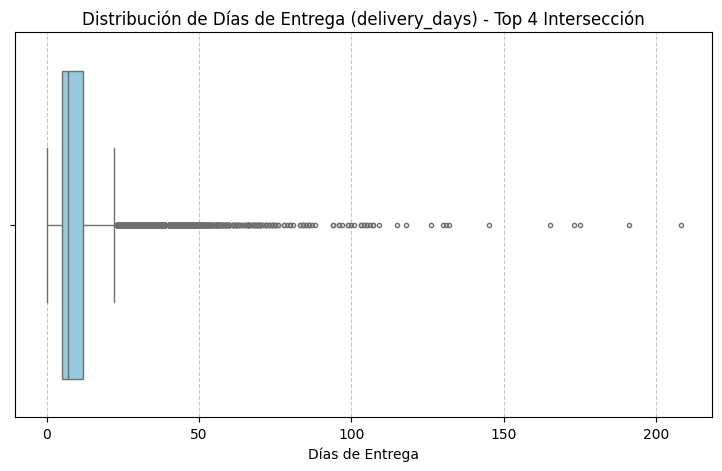

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del gráfico de caja (boxplot) para la variable objetivo
plt.figure(figsize=(9, 5))
sns.boxplot(x=df_subset_top_sellers_customers['delivery_days'], color='skyblue', fliersize=3)
plt.title('Distribución de Días de Entrega (delivery_days) - Top 4 Intersección', fontsize=12)
plt.xlabel('Días de Entrega', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Calcular Q1, Q3 y el rango intercuartílico (IQR) para 'delivery_days'
Q1 = df_subset_top_sellers_customers['delivery_days'].quantile(0.25)
Q3 = df_subset_top_sellers_customers['delivery_days'].quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para identificar valores atípicos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtrar el DataFrame excluyendo los valores atípicos
df_subset_clean = df_subset_top_sellers_customers[
    (df_subset_top_sellers_customers['delivery_days'] >= limite_inferior) &
    (df_subset_top_sellers_customers['delivery_days'] <= limite_superior)
].copy()

# Verificación del impacto del filtro
print(f"Registros originales: {len(df_subset_top_sellers_customers):,}")
print(f"Registros después de remover atípicos: {len(df_subset_clean):,}")
print(f"Registros eliminados: {len(df_subset_top_sellers_customers) - len(df_subset_clean):,}")
print(f"Límite superior aplicado: {limite_superior:.2f} días")

Registros originales: 48,620
Registros después de remover atípicos: 45,641
Registros eliminados: 2,979
Límite superior aplicado: 22.50 días


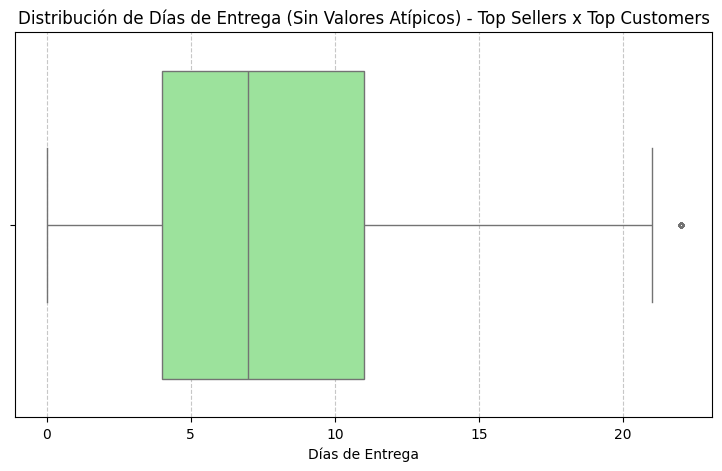

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del boxplot con el dataset limpio de valores atípicos
plt.figure(figsize=(9, 5))
sns.boxplot(x=df_subset_clean['delivery_days'], color='lightgreen', fliersize=3)
plt.title('Distribución de Días de Entrega (Sin Valores Atípicos) - Top Sellers x Top Customers', fontsize=12)
plt.xlabel('Días de Entrega', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Obtener el Top 10 de categorías de productos según el criterio de precio, peso y volumen
top_10_precio = df_subset_clean['principal_category_by_price'].value_counts().head(10)
top_10_peso = df_subset_clean['principal_category_by_weight'].value_counts().head(10)
top_10_volumen = df_subset_clean['principal_category_by_volume'].value_counts().head(10)

print("--- TOP 10 CATEGORÍAS (PRINCIPAL POR PRECIO) ---")
print(top_10_precio)

print("\n--- TOP 10 CATEGORÍAS (PRINCIPAL POR PESO) ---")
print(top_10_peso)

print("\n--- TOP 10 CATEGORÍAS (PRINCIPAL POR VOLUMEN) ---")
print(top_10_volumen)

--- TOP 10 CATEGORÍAS (PRINCIPAL POR PRECIO) ---
principal_category_by_price
cama_mesa_banho           4956
beleza_saude              3975
esporte_lazer             3456
moveis_decoracao          3101
utilidades_domesticas     3003
informatica_acessorios    2765
relogios_presentes        2522
brinquedos                1804
automotivo                1756
telefonia                 1642
Name: count, dtype: int64

--- TOP 10 CATEGORÍAS (PRINCIPAL POR PESO) ---
principal_category_by_weight
cama_mesa_banho           4946
beleza_saude              3971
esporte_lazer             3457
moveis_decoracao          3111
utilidades_domesticas     3001
informatica_acessorios    2764
relogios_presentes        2515
brinquedos                1797
automotivo                1758
telefonia                 1639
Name: count, dtype: int64

--- TOP 10 CATEGORÍAS (PRINCIPAL POR VOLUMEN) ---
principal_category_by_volume
cama_mesa_banho           4935
beleza_saude              3975
esporte_lazer             3461
m

In [ ]:
# 1. Obtener el top 8 de categorías principales por peso utilizando el nombre correcto de la columna
top_8_categorias_list = df_subset_clean['principal_category_by_weight'].value_counts().head(8).index.tolist()

# 2. Crear el dataset final filtrando por esas 8 categorías
df_final_modeling_ready = df_subset_clean[
    df_subset_clean['principal_category_by_weight'].isin(top_8_categorias_list)
].copy()

# 3. Verificación de las categorías seleccionadas y el conteo de registros
print("Top 8 Categorías (por peso):")
print(top_8_categorias_list)
print("-" * 50)
print(f"Total de registros en el dataset final de modelado: {len(df_final_modeling_ready):,}")

Top 8 Categorías (por peso):
['cama_mesa_banho', 'beleza_saude', 'esporte_lazer', 'moveis_decoracao', 'utilidades_domesticas', 'informatica_acessorios', 'relogios_presentes', 'brinquedos']
--------------------------------------------------
Total de registros en el dataset final de modelado: 25,562


In [ ]:
df_final_modeling_ready.head()

,order_id,customer_id,order_status,customer_unique_id,customer_state,total_payment_value,payment_count,principal_payment_type,total_price,total_freight,...,dias_entrega_promedio_t2,transacciones_count_t2,facturacion_total_t2,peso_total_t2,volumen_total_t2,transacciones_count_prev_month,facturacion_total_prev_month,peso_total_prev_month,volumen_total_prev_month,dias_entrega_promedio_prev_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,7c396fd4830fd04220f754e42b4e5bff,SP,38.71,3.0,voucher,29.99,8.72,...,10.043478,46.0,4692.95,51030.0,518401.0,3965.0,670205.77,9990156.0,76214708.0,11.886244
12,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,e2dfa3127fedbbca9707b36304996dab,SP,32.70,1.0,credit_card,19.90,12.80,...,9.063401,347.0,54731.84,733417.0,5084523.0,6829.0,1171086.67,15658277.0,107505366.0,11.552505
13,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,delivered,04cf8185c71090d28baa4407b2e6d600,SP,54.36,1.0,credit_card,38.25,16.11,...,15.841772,316.0,50299.60,745211.0,5213955.0,5850.0,875514.19,14056426.0,97426958.0,14.586934
17,85ce859fd6dc634de8d2f1e290444043,059f7fc5719c7da6cbafe370971a8d70,delivered,d0ff1a7468fcc46b8fc658ab35d2a12c,SP,29.75,1.0,credit_card,17.90,11.85,...,12.000000,4.0,2609.90,8777.0,42774.0,4494.0,759903.98,10796090.0,82624128.0,11.846389
19,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,d699688533772c15a061e8ce81cb56df,SP,118.86,1.0,boleto,109.90,8.96,...,10.369565,46.0,8211.83,93246.0,675035.0,4302.0,627367.19,10709471.0,81916895.0,11.021440


In [ ]:
# Asegurar que purchase_date es de tipo datetime
df_final_modeling_ready['purchase_date'] = pd.to_datetime(df_final_modeling_ready['purchase_date'])

# Extraer explícitamente año, mes y día de forma independiente si no existen
if 'purchase_year' not in df_final_modeling_ready.columns:
    df_final_modeling_ready['purchase_year'] = df_final_modeling_ready['purchase_date'].dt.year

if 'purchase_month' not in df_final_modeling_ready.columns:
    df_final_modeling_ready['purchase_month'] = df_final_modeling_ready['purchase_date'].dt.month

if 'purchase_day' not in df_final_modeling_ready.columns:
    df_final_modeling_ready['purchase_day'] = df_final_modeling_ready['purchase_date'].dt.day

print("Columnas de fecha extraídas/verificadas con éxito:")
print(df_final_modeling_ready[['purchase_date', 'purchase_year', 'purchase_month', 'purchase_day']].head())

Columnas de fecha extraídas/verificadas con éxito:
   purchase_date  purchase_year  purchase_month  purchase_day
0     2017-10-02           2017              10             2
12    2018-07-25           2018               7            25
13    2018-03-01           2018               3             1
17    2017-11-21           2017              11            21
19    2017-09-18           2017               9            18


In [ ]:
print(df_final_modeling_ready.columns.tolist())

['order_id', 'customer_id', 'order_status', 'customer_unique_id', 'customer_state', 'total_payment_value', 'payment_count', 'principal_payment_type', 'total_price', 'total_freight', 'total_weight_g', 'total_volume_cm3', 'seller_state_count', 'category_count', 'principal_category_by_price', 'principal_seller_state_by_price', 'principal_category_by_weight', 'principal_seller_state_by_weight', 'principal_category_by_volume', 'principal_seller_state_by_volume', 'delivery_days', 'purchase_date', 'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour', 'delivery_date', 'delivery_day', 'delivery_hour', 'estado_red_fecha_origen', 'transacciones_count_t1', 'facturacion_total_t1', 'facturacion_promedio', 'facturacion_mediana', 'facturacion_std', 'peso_total_t1', 'peso_promedio', 'peso_mediana', 'peso_std', 'volumen_total_t1', 'volumen_promedio', 'volumen_mediana', 'volumen_std', 'dias_entrega_total', 'dias_entrega_promedio_t1', 'dias_entrega_mediana', 'dias_entrega_std', 'transaccion

In [ ]:
import pandas as pd

# 1. Filtrar las columnas correspondientes a retardos y ventanas históricas
lag_historical_columns = [
    col for col in df_final_modeling_ready.columns
    if any(term in col for term in ['t1', 't2', '7d_avg', 'prev_month'])
]

# 2. Calcular la cantidad y el porcentaje de valores nulos (NaN)
nulls_summary = pd.DataFrame({
    'Cantidad de Nulos': df_final_modeling_ready[lag_historical_columns].isnull().sum(),
    'Porcentaje (%)': (df_final_modeling_ready[lag_historical_columns].isnull().mean() * 100).round(2),
    'Total de Registros': len(df_final_modeling_ready)
})

print("--- RECUENTO DE VALORES NULOS EN VARIABLES HISTÓRICAS / LAGS ---")
print(nulls_summary[nulls_summary['Cantidad de Nulos'] > 0])

--- RECUENTO DE VALORES NULOS EN VARIABLES HISTÓRICAS / LAGS ---
                                  Cantidad de Nulos  Porcentaje (%)  \
transacciones_count_t1                          380            1.49   
facturacion_total_t1                            380            1.49   
peso_total_t1                                   380            1.49   
volumen_total_t1                                380            1.49   
dias_entrega_promedio_t1                        380            1.49   
transacciones_count_7d_avg                      380            1.49   
facturacion_total_7d_avg                        380            1.49   
peso_total_7d_avg                               380            1.49   
volumen_total_7d_avg                            380            1.49   
dias_entrega_promedio_7d_avg                    380            1.49   
dias_entrega_promedio_t2                        729            2.85   
transacciones_count_t2                          729            2.85   
facturacion_

In [ ]:
import pandas as pd

# 1. Identificar columnas históricas y de lag
lag_historical_columns = [
    col for col in df_final_modeling_ready.columns
    if any(term in col for term in ['t1', 't2', '7d_avg', 'prev_month'])
]

# 2. Filtrar filas con al menos un valor nulo
null_rows = df_final_modeling_ready[
    df_final_modeling_ready[lag_historical_columns].isnull().any(axis=1)
].copy()

# Agregar el día de la semana
null_rows['dia_semana'] = null_rows['purchase_date'].dt.day_name()

# 3. Recuento por fecha
recuento_por_fecha = (
    null_rows.groupby('purchase_date')
    .size()
    .reset_index(name='cantidad_registros_nulos')
    .sort_values('purchase_date')
)

# 4. Recuento por día de la semana
recuento_por_dia = (
    null_rows.groupby('dia_semana')
    .size()
    .reset_index(name='cantidad_registros_nulos')
    .sort_values('cantidad_registros_nulos', ascending=False)
)

print("--- RECUENTO POR FECHA ---")
print(recuento_por_fecha.to_string(index=False))

print("\n--- RECUENTO POR DÍA DE LA SEMANA ---")
print(recuento_por_dia.to_string(index=False))

--- RECUENTO POR FECHA ---
purchase_date  cantidad_registros_nulos
   2017-01-07                         1
   2017-01-08                         1
   2017-01-09                         1
   2017-01-10                         2
   2017-01-11                         1
   2017-01-12                         3
   2017-01-15                         5
   2017-01-16                         4
   2017-01-17                        12
   2017-01-23                         8
   2017-01-24                        10
   2017-01-30                        12
   2017-01-31                        15
   2017-02-06                        27
   2017-02-07                        31
   2017-02-19                        11
   2017-02-20                        18
   2017-02-27                        12
   2017-02-28                        15
   2017-03-01                        27
   2017-03-02                        15
   2017-04-17                        13
   2017-04-18                        14
   2017-08-07

In [ ]:
# 1. Identificar columnas históricas y de lag
lag_historical_columns = [
    col for col in df_final_modeling_ready.columns
    if any(term in col for term in ['t1', 't2', '7d_avg', 'prev_month'])
]

# 2. Filtrar filas con al menos un valor nulo
null_rows = df_final_modeling_ready[
    df_final_modeling_ready[lag_historical_columns].isnull().any(axis=1)
]

# 3. Calcular la fecha mínima y máxima entre los registros afectados
fecha_minima = null_rows['purchase_date'].min()
fecha_maxima = null_rows['purchase_date'].max()

print(f"Fecha mínima con valores nulos: {fecha_minima}")
print(f"Fecha máxima con valores nulos: {fecha_maxima}")

Fecha mínima con valores nulos: 2017-01-07 00:00:00
Fecha máxima con valores nulos: 2018-02-15 00:00:00


In [ ]:
import pandas as pd

# Asegurar que la librería 'holidays' esté disponible para los festivos de Brasil
try:
    import holidays
except ImportError:
    import os
    os.system('pip install holidays')
    import holidays

# 1. Crear el rango de fechas entre la mínima y máxima reportada
date_range = pd.date_range(start='2017-01-07', end='2018-10-15')

# 2. Cargar los festivos oficiales de Brasil para los años 2017 y 2018
br_holidays = holidays.Brazil(years=[2017, 2018])

# 3. Construir el DataFrame de calendario con las verificaciones
df_calendar = pd.DataFrame({'fecha': date_range})
df_calendar['dia_semana'] = df_calendar['fecha'].dt.day_name()
df_calendar['es_domingo'] = (df_calendar['fecha'].dt.dayofweek == 6).astype(int)
df_calendar['es_festivo'] = df_calendar['fecha'].apply(lambda x: x in br_holidays).astype(int)
df_calendar['nombre_festivo'] = df_calendar['fecha'].apply(lambda x: br_holidays.get(x, ''))

# 4. Filtrar exclusivamente los días que sean domingo o algún día festivo de Brasil
df_domingos_festivos = df_calendar[
    (df_calendar['es_domingo'] == 1) | (df_calendar['es_festivo'] == 1)
].copy()

print(f"Total de días resaltados (Domingos y/o Festivos): {len(df_domingos_festivos):,}")
print("\nMuestra de los primeros días resaltados:")
print(df_domingos_festivos.head(15).to_string(index=False))

Total de días resaltados (Domingos y/o Festivos): 107

Muestra de los primeros días resaltados:
     fecha dia_semana  es_domingo  es_festivo nombre_festivo
2017-01-08     Sunday           1           0               
2017-01-15     Sunday           1           0               
2017-01-22     Sunday           1           0               
2017-01-29     Sunday           1           0               
2017-02-05     Sunday           1           0               
2017-02-12     Sunday           1           0               
2017-02-19     Sunday           1           0               
2017-02-26     Sunday           1           0               
2017-03-05     Sunday           1           0               
2017-03-12     Sunday           1           0               
2017-03-19     Sunday           1           0               
2017-03-26     Sunday           1           0               
2017-04-02     Sunday           1           0               
2017-04-09     Sunday           1           0     

In [ ]:
df_final_modeling_ready.columns

Index(['order_id', 'customer_id', 'order_status', 'customer_unique_id',
       'customer_state', 'total_payment_value', 'payment_count',
       'principal_payment_type', 'total_price', 'total_freight',
       'total_weight_g', 'total_volume_cm3', 'seller_state_count',
       'category_count', 'principal_category_by_price',
       'principal_seller_state_by_price', 'principal_category_by_weight',
       'principal_seller_state_by_weight', 'principal_category_by_volume',
       'principal_seller_state_by_volume', 'delivery_days', 'purchase_date',
       'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour',
       'delivery_date', 'delivery_day', 'delivery_hour',
       'estado_red_fecha_origen', 'transacciones_count_t1',
       'facturacion_total_t1', 'facturacion_promedio', 'facturacion_mediana',
       'facturacion_std', 'peso_total_t1', 'peso_promedio', 'peso_mediana',
       'peso_std', 'volumen_total_t1', 'volumen_promedio', 'volumen_mediana',
       'volumen_std', 'd

In [ ]:
# 1. Crear copia del dataframe original
df_final_modeling_ready_v2 = df_final_modeling_ready.copy()

# 2. Asegurar que purchase_date esté en formato datetime (solo fecha, sin hora)
df_final_modeling_ready_v2['purchase_date'] = pd.to_datetime(df_final_modeling_ready_v2['purchase_date']).dt.normalize()

# 3. Crear un set de fechas (domingo o festivo) DESPLAZADAS +1 día para comparación
fechas_domingo_festivo_mas1 = set(
    pd.to_datetime(df_domingos_festivos['fecha']).dt.normalize() + pd.Timedelta(days=1)
)

# 4. Crear la nueva columna: 1 si purchase_date coincide con (fecha_festivo + 1 día), 0 si no
df_final_modeling_ready_v2['es_domingo_o_festivo'] = df_final_modeling_ready_v2['purchase_date'].isin(fechas_domingo_festivo_mas1).astype(int)

# Verificación rápida
print(df_final_modeling_ready_v2['es_domingo_o_festivo'].value_counts())

es_domingo_o_festivo
0    20903
1     4659
Name: count, dtype: int64


In [ ]:
# 1. Crear un set de fechas (domingo o festivo) SIN desplazar
fechas_domingo_festivo_exactas = set(pd.to_datetime(df_domingos_festivos['fecha']).dt.normalize())

# 2. Crear la nueva columna: 1 si purchase_date coincide exactamente con domingo o festivo
df_final_modeling_ready_v2['es_domingo_o_festivo_exacto'] = df_final_modeling_ready_v2['purchase_date'].isin(fechas_domingo_festivo_exactas).astype(int)

# Verificación rápida de ambas columnas
print("Distribución del mismo día (Domingo/Festivo exacto):")
print(df_final_modeling_ready_v2['es_domingo_o_festivo_exacto'].value_counts())

Distribución del mismo día (Domingo/Festivo exacto):
es_domingo_o_festivo_exacto
0    22050
1     3512
Name: count, dtype: int64


In [ ]:
# 1. Crear columna: 1 si es domingo (en pandas, Lunes=0 y Domingo=6)
df_final_modeling_ready_v2['es_domingo'] = (df_final_modeling_ready_v2['purchase_date'].dt.dayofweek == 6).astype(int)

# 2. Crear columna: 1 si es lunes
df_final_modeling_ready_v2['es_lunes'] = (df_final_modeling_ready_v2['purchase_date'].dt.dayofweek == 0).astype(int)

# 3. Crear columna: 1 si el mes es diciembre (mes 12)
df_final_modeling_ready_v2['es_diciembre'] = (df_final_modeling_ready_v2['purchase_date'].dt.month == 12).astype(int)

# Verificación rápida de cuántos registros hay en cada categoría
print("Total de compras en Domingo:", df_final_modeling_ready_v2['es_domingo'].sum())
print("Total de compras en Lunes:", df_final_modeling_ready_v2['es_lunes'].sum())
print("Total de compras en Diciembre:", df_final_modeling_ready_v2['es_diciembre'].sum())

Total de compras en Domingo: 3143
Total de compras en Lunes: 4201
Total de compras en Diciembre: 1332


In [ ]:
df_final_modeling_ready_v2.columns


Index(['order_id', 'customer_id', 'order_status', 'customer_unique_id',
       'customer_state', 'total_payment_value', 'payment_count',
       'principal_payment_type', 'total_price', 'total_freight',
       'total_weight_g', 'total_volume_cm3', 'seller_state_count',
       'category_count', 'principal_category_by_price',
       'principal_seller_state_by_price', 'principal_category_by_weight',
       'principal_seller_state_by_weight', 'principal_category_by_volume',
       'principal_seller_state_by_volume', 'delivery_days', 'purchase_date',
       'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour',
       'delivery_date', 'delivery_day', 'delivery_hour',
       'estado_red_fecha_origen', 'transacciones_count_t1',
       'facturacion_total_t1', 'facturacion_promedio', 'facturacion_mediana',
       'facturacion_std', 'peso_total_t1', 'peso_promedio', 'peso_mediana',
       'peso_std', 'volumen_total_t1', 'volumen_promedio', 'volumen_mediana',
       'volumen_std', 'd

In [ ]:
# 1. Identificar columnas de la ventana t1
cols_t1 = ['transacciones_count_t1', 'facturacion_total_t1',
           'peso_total_t1', 'volumen_total_t1', 'dias_entrega_promedio_t1']

# 2. Filtrar filas donde TODAS las columnas t1 son nulas
df_t1_nulo = df_final_modeling_ready_v2[df_final_modeling_ready_v2[cols_t1].isnull().all(axis=1)].copy()

print(f"Total de filas con t1 nulo: {len(df_t1_nulo):,}")

# 3. Crear columna de día de la semana (por si no existe ya en este subset)
df_t1_nulo['dia_semana'] = df_t1_nulo['purchase_date'].dt.day_name()

# 4. Resumen agrupado por fecha
resumen_por_fecha = df_t1_nulo.groupby('purchase_date').agg(
    suma_domingo_festivo=('es_domingo_o_festivo', 'sum'),
    conteo=('es_domingo_o_festivo', 'count')
).reset_index()

print("\nResumen por fecha:")
print(resumen_por_fecha.to_string(index=False))

# 5. Resumen agrupado por día de la semana
resumen_por_dia_semana = df_t1_nulo.groupby('dia_semana').agg(
    suma_domingo_festivo=('es_domingo_o_festivo', 'sum'),
    conteo=('es_domingo_o_festivo', 'count')
).reset_index()

print("\nResumen por día de la semana:")
print(resumen_por_dia_semana.to_string(index=False))

Total de filas con t1 nulo: 380

Resumen por fecha:
purchase_date  suma_domingo_festivo  conteo
   2017-01-07                     0       1
   2017-01-08                     0       1
   2017-01-09                     1       1
   2017-01-10                     0       2
   2017-01-11                     0       1
   2017-01-15                     0       5
   2017-01-16                     4       4
   2017-01-23                     8       8
   2017-01-30                    12      12
   2017-02-06                    27      27
   2017-02-19                     0      11
   2017-02-27                    12      12
   2017-03-01                     0      27
   2017-04-17                    13      13
   2017-08-07                    45      45
   2017-09-04                    40      40
   2017-11-06                    48      48
   2017-12-26                    46      46
   2018-02-14                     0      76

Resumen por día de la semana:
dia_semana  suma_domingo_festivo  con

In [ ]:
# Verificación cruzada (Día desplazado vs Día exacto)
print(pd.crosstab(df_final_modeling_ready_v2['es_domingo_o_festivo'],
                  df_final_modeling_ready_v2['es_domingo_o_festivo_exacto'],
                  rownames=['es_domingo_o_festivo (Día después)'],
                  colnames=['es_domingo_o_festivo_exacto (Mismo día)']))

es_domingo_o_festivo_exacto (Mismo día)      0     1
es_domingo_o_festivo (Día después)                  
0                                        17510  3393
1                                         4540   119


In [ ]:
# 1. Diccionario de renombrado: mayor claridad para columnas t1 y variables de calendario
diccionario_renombrado = {
    # Arreglar sufijos de la ventana t1
    'facturacion_promedio': 'facturacion_promedio_t1',
    'facturacion_mediana': 'facturacion_mediana_t1',
    'facturacion_std': 'facturacion_std_t1',
    'peso_promedio': 'peso_promedio_t1',
    'peso_mediana': 'peso_mediana_t1',
    'peso_std': 'peso_std_t1',
    'volumen_promedio': 'volumen_promedio_t1',
    'volumen_mediana': 'volumen_mediana_t1',
    'volumen_std': 'volumen_std_t1',
    'dias_entrega_total': 'dias_entrega_total_t1',
    'dias_entrega_mediana': 'dias_entrega_mediana_t1',
    'dias_entrega_std': 'dias_entrega_std_t1',

    # Desambiguar las variables de festivos/domingos
    'es_domingo_o_festivo': 'es_post_domingo_festivo',  # La que desplazamos +1 día
    'es_domingo_o_festivo_exacto': 'es_domingo_festivo_mismo_dia' # La que coincide exactamente
}

# 2. Aplicar el renombrado
df_final_modeling_ready_v2 = df_final_modeling_ready_v2.rename(columns=diccionario_renombrado)

# Verificación rápida
print("Nuevas columnas t1:")
print([c for c in df_final_modeling_ready_v2.columns if c.endswith('_t1')])

print("\nNuevas columnas de calendario:")
print([c for c in df_final_modeling_ready_v2.columns if 'domingo' in c or 'festivo' in c])

Nuevas columnas t1:
['transacciones_count_t1', 'facturacion_total_t1', 'facturacion_promedio_t1', 'facturacion_mediana_t1', 'facturacion_std_t1', 'peso_total_t1', 'peso_promedio_t1', 'peso_mediana_t1', 'peso_std_t1', 'volumen_total_t1', 'volumen_promedio_t1', 'volumen_mediana_t1', 'volumen_std_t1', 'dias_entrega_total_t1', 'dias_entrega_promedio_t1', 'dias_entrega_mediana_t1', 'dias_entrega_std_t1']

Nuevas columnas de calendario:
['es_post_domingo_festivo', 'es_domingo_festivo_mismo_dia', 'es_domingo']


In [ ]:
# 1. Lista completa de columnas lageadas (con nombres ya actualizados)
cols_lageadas = [
    # Ventana t1
    'transacciones_count_t1',
    'facturacion_total_t1',
    'facturacion_promedio_t1',
    'facturacion_mediana_t1',
    'facturacion_std_t1',
    'peso_total_t1',
    'peso_promedio_t1',
    'peso_mediana_t1',
    'peso_std_t1',
    'volumen_total_t1',
    'volumen_promedio_t1',
    'volumen_mediana_t1',
    'volumen_std_t1',
    'dias_entrega_total_t1',
    'dias_entrega_promedio_t1',
    'dias_entrega_mediana_t1',
    'dias_entrega_std_t1',
    # Ventana 7 días
    'transacciones_count_7d_avg',
    'facturacion_total_7d_avg',
    'peso_total_7d_avg',
    'volumen_total_7d_avg',
    'dias_entrega_promedio_7d_avg',
    # Ventana t2
    'transacciones_count_t2',
    'facturacion_total_t2',
    'peso_total_t2',
    'volumen_total_t2',
    'dias_entrega_promedio_t2',
    # Mes anterior
    'transacciones_count_prev_month',
    'facturacion_total_prev_month',
    'peso_total_prev_month',
    'volumen_total_prev_month',
    'dias_entrega_promedio_prev_month',
]

# 2. Verificación previa: cuántos nulos hay por columna antes de rellenar
print("Nulos antes de rellenar:")
print(df_final_modeling_ready_v2[cols_lageadas].isnull().sum())

# 3. Rellenar nulos con 0
df_final_modeling_ready_v2[cols_lageadas] = df_final_modeling_ready_v2[cols_lageadas].fillna(0)

# 4. Verificación posterior: confirmar que ya no quedan nulos
print("\nNulos después de rellenar:")
print(df_final_modeling_ready_v2[cols_lageadas].isnull().sum())

Nulos antes de rellenar:
transacciones_count_t1              380
facturacion_total_t1                380
facturacion_promedio_t1             380
facturacion_mediana_t1              380
facturacion_std_t1                  778
peso_total_t1                       380
peso_promedio_t1                    380
peso_mediana_t1                     380
peso_std_t1                         778
volumen_total_t1                    380
volumen_promedio_t1                 380
volumen_mediana_t1                  380
volumen_std_t1                      778
dias_entrega_total_t1               380
dias_entrega_promedio_t1            380
dias_entrega_mediana_t1             380
dias_entrega_std_t1                 778
transacciones_count_7d_avg          380
facturacion_total_7d_avg            380
peso_total_7d_avg                   380
volumen_total_7d_avg                380
dias_entrega_promedio_7d_avg        380
transacciones_count_t2              729
facturacion_total_t2                729
peso_total_t2  

In [ ]:
df_final_modeling_ready_v2.columns

Index(['order_id', 'customer_id', 'order_status', 'customer_unique_id',
       'customer_state', 'total_payment_value', 'payment_count',
       'principal_payment_type', 'total_price', 'total_freight',
       'total_weight_g', 'total_volume_cm3', 'seller_state_count',
       'category_count', 'principal_category_by_price',
       'principal_seller_state_by_price', 'principal_category_by_weight',
       'principal_seller_state_by_weight', 'principal_category_by_volume',
       'principal_seller_state_by_volume', 'delivery_days', 'purchase_date',
       'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour',
       'delivery_date', 'delivery_day', 'delivery_hour',
       'estado_red_fecha_origen', 'transacciones_count_t1',
       'facturacion_total_t1', 'facturacion_promedio_t1',
       'facturacion_mediana_t1', 'facturacion_std_t1', 'peso_total_t1',
       'peso_promedio_t1', 'peso_mediana_t1', 'peso_std_t1',
       'volumen_total_t1', 'volumen_promedio_t1', 'volumen_median

In [ ]:
# 1. Listas de referencia (basadas en la variable de peso)
categorias_peso = df_final_modeling_ready_v2['principal_category_by_weight'].dropna().unique().tolist()
estados_peso = df_final_modeling_ready_v2['principal_seller_state_by_weight'].dropna().unique().tolist()

print(f"Total de categorías distintas (peso): {len(categorias_peso)}")
print(f"Total de estados distintos (peso): {len(estados_peso)}")

# 2. Filtrar: category_by_price/volume Y seller_state_by_price/volume
#    deben estar dentro de sus respectivas listas de peso
df_filtrado = df_final_modeling_ready_v2[
    (df_final_modeling_ready_v2['principal_category_by_price'].isin(categorias_peso)) &
    (df_final_modeling_ready_v2['principal_category_by_volume'].isin(categorias_peso)) &
    (df_final_modeling_ready_v2['principal_seller_state_by_price'].isin(estados_peso)) &
    (df_final_modeling_ready_v2['principal_seller_state_by_volume'].isin(estados_peso))
].copy()

print(f"\nFilas antes del filtro: {len(df_final_modeling_ready_v2):,}")
print(f"Filas después del filtro: {len(df_filtrado):,}")
print(f"Filas eliminadas: {len(df_final_modeling_ready_v2) - len(df_filtrado):,}")

Total de categorías distintas (peso): 8
Total de estados distintos (peso): 6

Filas antes del filtro: 25,562
Filas después del filtro: 25,516
Filas eliminadas: 46


In [ ]:
# ============================================================
# 1. Verificar columnas de fecha ya existentes (para no recrear)
# ============================================================
print(df_filtrado[['purchase_date', 'purchase_day', 'purchase_month',
                    'purchase_year', 'purchase_hour', 'purchase_time']].head(10))

   purchase_date  purchase_day  purchase_month  purchase_year  purchase_hour  \
0     2017-10-02             2              10           2017             10   
12    2018-07-25            25               7           2018             17   
13    2018-03-01             1               3           2018             14   
17    2017-11-21            21              11           2017              0   
19    2017-09-18            18               9           2017             14   
20    2018-03-15            15               3           2018              8   
27    2018-05-02             2               5           2018             11   
31    2017-12-12            12              12           2017             13   
32    2018-02-03             3               2           2018             12   
36    2017-07-31            31               7           2017             21   

   purchase_time  
0       10:56:33  
12      17:44:10  
13      14:14:28  
17      00:03:41  
19      14:31:30  
20   

In [ ]:
# ============================================================
# 2. Eliminar columnas con fuga de datos / no necesarias
# ============================================================
cols_a_eliminar = ['order_status', 'delivery_date', 'delivery_day', 'delivery_hour']
df_filtrado = df_filtrado.drop(columns=cols_a_eliminar)

print(f"Columnas eliminadas: {cols_a_eliminar}")
print(f"Total de columnas restantes: {df_filtrado.shape[1]}")

# ============================================================
# 3. Columna: franja horaria de la compra (mañana/tarde/noche)
# ============================================================
def clasificar_franja_horaria(hora):
    if 5 <= hora < 12:
        return 'mañana'
    elif 12 <= hora < 19:
        return 'tarde'
    else:
        return 'noche'

df_filtrado['franja_horaria_compra'] = df_filtrado['purchase_hour'].apply(clasificar_franja_horaria)

# ============================================================
# 4. Columna: día de la semana de la compra
# ============================================================
df_filtrado['dia_semana_compra'] = df_filtrado['purchase_date'].dt.day_name()

# ============================================================
# 5. Columna: 1 si la compra fue viernes, sábado o domingo; 0 si no
# ============================================================
dias_fin_semana = ['Friday', 'Saturday', 'Sunday']
df_filtrado['es_fin_de_semana_extendido'] = df_filtrado['dia_semana_compra'].isin(dias_fin_semana).astype(int)

# Verificación rápida
print(df_filtrado[['purchase_hour', 'franja_horaria_compra',
                    'dia_semana_compra', 'es_fin_de_semana_extendido']].head(10))
print("\nDistribución franja horaria:")
print(df_filtrado['franja_horaria_compra'].value_counts())
print("\nDistribución fin de semana extendido:")
print(df_filtrado['es_fin_de_semana_extendido'].value_counts())

Columnas eliminadas: ['order_status', 'delivery_date', 'delivery_day', 'delivery_hour']
Total de columnas restantes: 64
    purchase_hour franja_horaria_compra dia_semana_compra  \
0              10                mañana            Monday   
12             17                 tarde         Wednesday   
13             14                 tarde          Thursday   
17              0                 noche           Tuesday   
19             14                 tarde            Monday   
20              8                mañana          Thursday   
27             11                mañana         Wednesday   
31             13                 tarde           Tuesday   
32             12                 tarde          Saturday   
36             21                 noche            Monday   

    es_fin_de_semana_extendido  
0                            0  
12                           0  
13                           0  
17                           0  
19                           0  
20        

In [ ]:
# ============================================================
# 6. Mover la variable objetivo (delivery_days) al final del dataframe
# ============================================================
target = 'delivery_days'
cols_sin_target = [c for c in df_filtrado.columns if c != target]
df_filtrado = df_filtrado[cols_sin_target + [target]]

# Verificación rápida
print(df_filtrado[['franja_horaria_compra', 'dia_semana_compra',
                    'es_fin_de_semana_extendido']].head(10))
print("\nÚltimas columnas del dataframe:")
print(df_filtrado.columns[-5:].tolist())

   franja_horaria_compra dia_semana_compra  es_fin_de_semana_extendido
0                 mañana            Monday                           0
12                 tarde         Wednesday                           0
13                 tarde          Thursday                           0
17                 noche           Tuesday                           0
19                 tarde            Monday                           0
20                mañana          Thursday                           0
27                mañana         Wednesday                           0
31                 tarde           Tuesday                           0
32                 tarde          Saturday                           1
36                 noche            Monday                           0

Últimas columnas del dataframe:
['es_diciembre', 'franja_horaria_compra', 'dia_semana_compra', 'es_fin_de_semana_extendido', 'delivery_days']


In [ ]:
df_filtrado.columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_state',
       'total_payment_value', 'payment_count', 'principal_payment_type',
       'total_price', 'total_freight', 'total_weight_g', 'total_volume_cm3',
       'seller_state_count', 'category_count', 'principal_category_by_price',
       'principal_seller_state_by_price', 'principal_category_by_weight',
       'principal_seller_state_by_weight', 'principal_category_by_volume',
       'principal_seller_state_by_volume', 'purchase_date', 'purchase_time',
       'purchase_month', 'purchase_year', 'purchase_hour',
       'estado_red_fecha_origen', 'transacciones_count_t1',
       'facturacion_total_t1', 'facturacion_promedio_t1',
       'facturacion_mediana_t1', 'facturacion_std_t1', 'peso_total_t1',
       'peso_promedio_t1', 'peso_mediana_t1', 'peso_std_t1',
       'volumen_total_t1', 'volumen_promedio_t1', 'volumen_mediana_t1',
       'volumen_std_t1', 'dias_entrega_total_t1', 'dias_entrega_promedio_t1',
       'dias

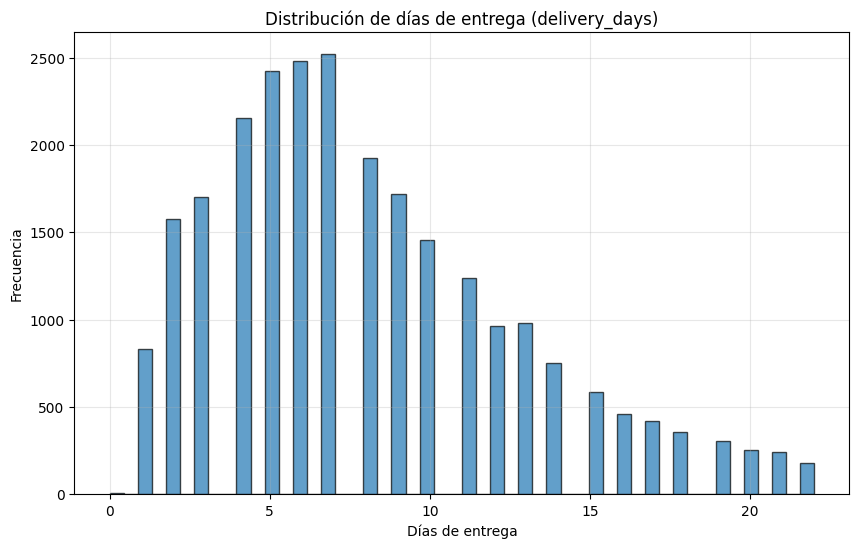

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df_filtrado['delivery_days'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribución de días de entrega (delivery_days)')
plt.xlabel('Días de entrega')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
conteo_dias = df_filtrado['delivery_days'].value_counts().sort_index()
print(conteo_dias)

delivery_days
0.0        8
1.0      832
2.0     1578
3.0     1703
4.0     2157
5.0     2425
6.0     2480
7.0     2520
8.0     1923
9.0     1718
10.0    1456
11.0    1238
12.0     961
13.0     978
14.0     750
15.0     584
16.0     457
17.0     422
18.0     355
19.0     302
20.0     251
21.0     241
22.0     177
Name: count, dtype: int64


In [ ]:
total = len(df_filtrado)
objetivo_por_grupo = total / 4

acumulado = conteo_dias.cumsum()
print(acumulado)
print(f"\nObjetivo por grupo: ~{objetivo_por_grupo:.0f} registros")

delivery_days
0.0         8
1.0       840
2.0      2418
3.0      4121
4.0      6278
5.0      8703
6.0     11183
7.0     13703
8.0     15626
9.0     17344
10.0    18800
11.0    20038
12.0    20999
13.0    21977
14.0    22727
15.0    23311
16.0    23768
17.0    24190
18.0    24545
19.0    24847
20.0    25098
21.0    25339
22.0    25516
Name: count, dtype: int64

Objetivo por grupo: ~6379 registros


In [ ]:
df_categorico = df_filtrado.copy()

bins = [0, 4, 7, 11, df_categorico['delivery_days'].max()]
labels = ['0-4 días', '5-7 días', '8-11 días', f'12-{int(bins[-1])} días']

df_categorico['delivery_category'] = pd.cut(
    df_categorico['delivery_days'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_categorico['delivery_category'] = pd.Categorical(
    df_categorico['delivery_category'], categories=labels, ordered=True
)

print(df_categorico['delivery_category'].value_counts().sort_index())

delivery_category
0-4 días      6278
5-7 días      7425
8-11 días     6335
12-22 días    5478
Name: count, dtype: int64


In [ ]:
print(df_categorico.groupby('delivery_category', observed=True)['delivery_days'].agg(['min', 'max', 'count']))

                    min   max  count
delivery_category                   
0-4 días            0.0   4.0   6278
5-7 días            5.0   7.0   7425
8-11 días           8.0  11.0   6335
12-22 días         12.0  22.0   5478


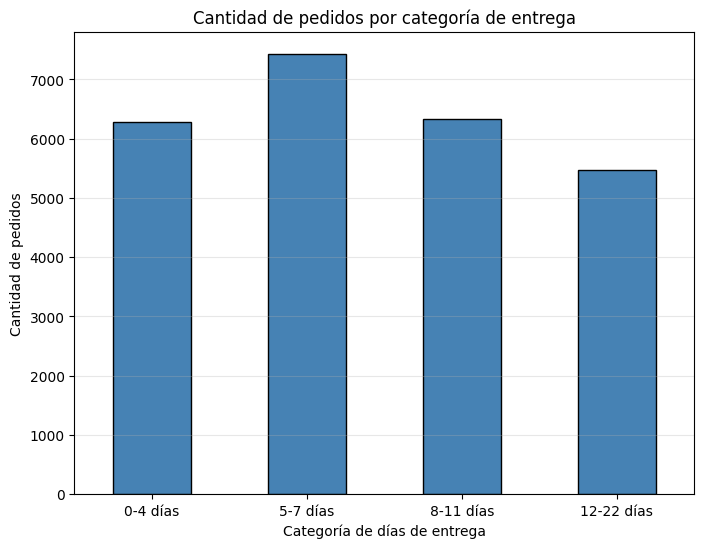

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
df_categorico['delivery_category'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Cantidad de pedidos por categoría de entrega')
plt.xlabel('Categoría de días de entrega')
plt.ylabel('Cantidad de pedidos')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [ ]:
df_categorico.columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_state',
       'total_payment_value', 'payment_count', 'principal_payment_type',
       'total_price', 'total_freight', 'total_weight_g', 'total_volume_cm3',
       'seller_state_count', 'category_count', 'principal_category_by_price',
       'principal_seller_state_by_price', 'principal_category_by_weight',
       'principal_seller_state_by_weight', 'principal_category_by_volume',
       'principal_seller_state_by_volume', 'purchase_date', 'purchase_time',
       'purchase_month', 'purchase_year', 'purchase_hour',
       'estado_red_fecha_origen', 'transacciones_count_t1',
       'facturacion_total_t1', 'facturacion_promedio_t1',
       'facturacion_mediana_t1', 'facturacion_std_t1', 'peso_total_t1',
       'peso_promedio_t1', 'peso_mediana_t1', 'peso_std_t1',
       'volumen_total_t1', 'volumen_promedio_t1', 'volumen_mediana_t1',
       'volumen_std_t1', 'dias_entrega_total_t1', 'dias_entrega_promedio_t1',
       'dias

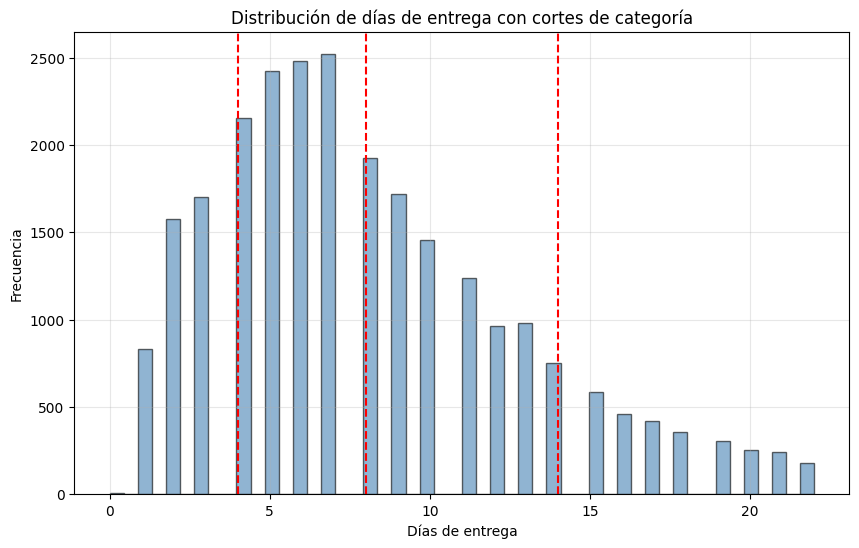

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df_filtrado['delivery_days'], bins=50, edgecolor='black', alpha=0.6, color='steelblue')

cortes = [4, 8, 14]
for corte in cortes:
    plt.axvline(corte, color='red', linestyle='--', linewidth=1.5)

plt.title('Distribución de días de entrega con cortes de categoría')
plt.xlabel('Días de entrega')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# from google.colab import files

# # 1. Guardar el DataFrame como un archivo CSV
# df_categorico.to_csv("df_categorico.csv", index=False)

# # 2. Descargar el archivo a tu computadora
# files.download("df_categorico.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_distancia = df_categorico.merge(customers_zip, on='customer_id', how='left')
df_distancia = df_distancia.merge(item_principal_zip, on='order_id', how='left')

print(df_distancia.shape)

(25516, 70)


In [ ]:
df_distancia = df_distancia.merge(
    geo_agg.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
                             'lat': 'customer_lat', 'lng': 'customer_lng'}),
    on='customer_zip_code_prefix', how='left'
)

df_distancia = df_distancia.merge(
    geo_agg.rename(columns={'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
                             'lat': 'seller_lat', 'lng': 'seller_lng'}),
    on='seller_zip_code_prefix', how='left'
)

print(df_distancia[['customer_lat','customer_lng','seller_lat','seller_lng']].isnull().sum())

customer_lat    8
customer_lng    8
seller_lat      7
seller_lng      7
dtype: int64


In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df_distancia['distancia_km'] = haversine(
    df_distancia['customer_lat'], df_distancia['customer_lng'],
    df_distancia['seller_lat'], df_distancia['seller_lng']
)

print(df_distancia['distancia_km'].describe())

count    25501.000000
mean       255.182142
std        208.203345
min          0.000000
25%         67.699796
50%        251.560440
75%        366.950798
max       2293.014539
Name: distancia_km, dtype: float64


In [ ]:
print(f"Filas antes de eliminar nulos: {df_distancia.shape[0]}")

df_distancia = df_distancia.dropna(subset=['distancia_km'])

print(f"Filas después de eliminar nulos: {df_distancia.shape[0]}")

df_distancia = df_distancia.drop(columns=['customer_zip_code_prefix', 'seller_zip_code_prefix',
                                            'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng'])

print(df_distancia.shape)
df_distancia.head()

Filas antes de eliminar nulos: 25516
Filas después de eliminar nulos: 25501
(25501, 69)


,order_id,customer_id,customer_unique_id,customer_state,total_payment_value,payment_count,principal_payment_type,total_price,total_freight,total_weight_g,...,es_domingo_festivo_mismo_dia,es_domingo,es_lunes,es_diciembre,franja_horaria_compra,dia_semana_compra,es_fin_de_semana_extendido,delivery_days,delivery_category,distancia_km
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,SP,38.71,3.0,voucher,29.99,8.72,500.0,...,0,0,1,0,mañana,Monday,0,8.0,8-11 días,18.576110
1,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,e2dfa3127fedbbca9707b36304996dab,SP,32.70,1.0,credit_card,19.90,12.80,200.0,...,0,0,0,0,tarde,Wednesday,0,4.0,0-4 días,309.131371
2,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,04cf8185c71090d28baa4407b2e6d600,SP,54.36,1.0,credit_card,38.25,16.11,583.0,...,0,0,0,0,tarde,Thursday,0,11.0,8-11 días,430.144201
3,85ce859fd6dc634de8d2f1e290444043,059f7fc5719c7da6cbafe370971a8d70,d0ff1a7468fcc46b8fc658ab35d2a12c,SP,29.75,1.0,credit_card,17.90,11.85,250.0,...,0,0,0,0,noche,Tuesday,0,6.0,5-7 días,209.757656
4,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,d699688533772c15a061e8ce81cb56df,SP,118.86,1.0,boleto,109.90,8.96,525.0,...,0,0,1,0,tarde,Monday,0,21.0,12-22 días,11.680956


In [ ]:
print(df_distancia.groupby('delivery_category', observed=True)['distancia_km'].mean())

delivery_category
0-4 días      112.637056
5-7 días      241.446352
8-11 días     313.321897
12-22 días    370.119137
Name: distancia_km, dtype: float64


In [ ]:
cols_seller_state = [
    'principal_seller_state_by_price',
    'principal_seller_state_by_weight',
    'principal_seller_state_by_volume'
]

for col in cols_seller_state:
    nueva_col = col.replace('principal_seller_state_by_', 'seller_sp_by_')
    df_distancia[nueva_col] = np.where(df_distancia[col] == 'SP', 'SP', 'Otro')

print(df_distancia[['seller_sp_by_price', 'seller_sp_by_weight', 'seller_sp_by_volume']].head())

  seller_sp_by_price seller_sp_by_weight seller_sp_by_volume
0                 SP                  SP                  SP
1                 SP                  SP                  SP
2                 SP                  SP                  SP
3                 SP                  SP                  SP
4                 SP                  SP                  SP


In [ ]:
for col in ['seller_sp_by_price', 'seller_sp_by_weight', 'seller_sp_by_volume']:
    print(df_distancia[col].value_counts())
    print()

seller_sp_by_price
SP      20189
Otro     5312
Name: count, dtype: int64

seller_sp_by_weight
SP      20200
Otro     5301
Name: count, dtype: int64

seller_sp_by_volume
SP      20190
Otro     5311
Name: count, dtype: int64



In [ ]:
df_distancia['delivery_date'] = pd.to_datetime(df_distancia['purchase_date']) + pd.to_timedelta(df_distancia['delivery_days'], unit='D')

In [ ]:
daily_distancia = df_distancia.groupby('delivery_date').agg(
    distancia_total=('distancia_km', 'sum'),
    distancia_promedio=('distancia_km', 'mean'),
    distancia_mediana=('distancia_km', 'median'),
    distancia_std=('distancia_km', 'std')
).reset_index()

daily_distancia = daily_distancia.sort_values('delivery_date')
print(daily_distancia.head())

  delivery_date  distancia_total  distancia_promedio  distancia_mediana  \
0    2017-01-16       595.871097          595.871097         595.871097   
1    2017-01-17       931.153382          465.576691         465.576691   
2    2017-01-18       539.272856          179.757619          26.106761   
3    2017-01-19      1229.084436          307.271109         268.287932   
4    2017-01-20       932.990437          310.996812         321.760092   

   distancia_std  
0            NaN  
1     125.535265  
2     271.622471  
3     195.715563  
4     269.919050  


In [ ]:
distancia_features = daily_distancia.set_index('delivery_date')

rolling_7d_dist = distancia_features[['distancia_total']].rolling(window='7D').mean().add_suffix('_7d_avg')

distancia_features = distancia_features.join(rolling_7d_dist).reset_index()

distancia_features['join_date'] = distancia_features['delivery_date'] + pd.Timedelta(days=1)
distancia_features['join_date'] = pd.to_datetime(distancia_features['join_date']).dt.date

distancia_features = distancia_features.rename(columns={
    'delivery_date': 'estado_red_fecha_origen_dist',
    'distancia_total': 'distancia_total_t1',
    'distancia_promedio': 'distancia_promedio_t1',
    'distancia_mediana': 'distancia_mediana_t1',
    'distancia_std': 'distancia_std_t1'
})

In [ ]:
distancia_t2 = daily_distancia[['delivery_date', 'distancia_total']].copy()

distancia_t2['join_date'] = distancia_t2['delivery_date'] + pd.Timedelta(days=2)
distancia_t2['join_date'] = pd.to_datetime(distancia_t2['join_date']).dt.date

distancia_t2 = distancia_t2.rename(columns={
    'distancia_total': 'distancia_total_t2'
}).drop(columns=['delivery_date'])

distancia_features = pd.merge(distancia_features, distancia_t2, on='join_date', how='left')

In [ ]:
daily_distancia['delivery_period'] = pd.to_datetime(daily_distancia['delivery_date']).dt.to_period('M')

monthly_distancia = daily_distancia.groupby('delivery_period').agg(
    distancia_total_prev_month=('distancia_total', 'sum')
).reset_index()

monthly_distancia['join_period'] = monthly_distancia['delivery_period'] + 1
monthly_distancia['join_year'] = monthly_distancia['join_period'].dt.year
monthly_distancia['join_month'] = monthly_distancia['join_period'].dt.month

monthly_distancia = monthly_distancia.drop(columns=['delivery_period', 'join_period'])

print("Features de distancia T-1, T-2, 7D y mes anterior listas.")

Features de distancia T-1, T-2, 7D y mes anterior listas.


In [ ]:
df_distancia['purchase_date_dt'] = pd.to_datetime(df_distancia['purchase_date']).dt.date

df_distancia = df_distancia.merge(
    distancia_features[['join_date', 'distancia_total_t1', 'distancia_promedio_t1',
                         'distancia_mediana_t1', 'distancia_std_t1',
                         'distancia_total_7d_avg', 'distancia_total_t2']],
    left_on='purchase_date_dt', right_on='join_date', how='left'
).drop(columns=['join_date'])

df_distancia = df_distancia.merge(
    monthly_distancia,
    left_on=['purchase_year', 'purchase_month'], right_on=['join_year', 'join_month'], how='left'
).drop(columns=['join_year', 'join_month'])

df_distancia = df_distancia.drop(columns=['purchase_date_dt', 'delivery_date'])

print(df_distancia.shape)
df_distancia.filter(like='distancia').head()

(25501, 79)


,distancia_km,distancia_total_t1,distancia_promedio_t1,distancia_mediana_t1,distancia_std_t1,distancia_total_7d_avg,distancia_total_t2,distancia_total_prev_month
0,18.576110,4025.883311,223.660184,270.636458,172.185009,12186.379352,4648.054362,291643.578332
1,309.131371,25252.144071,238.227774,171.938978,194.674139,12156.289915,28308.196726,489980.283895
2,430.144201,21694.682189,258.270026,226.147585,205.672360,17165.603663,20261.769786,422407.097607
3,209.757656,9623.066166,253.238583,265.356825,181.859458,8087.327987,1982.045834,345715.109856
4,11.680956,6110.978959,265.694737,283.776664,203.190214,9852.464828,1415.038738,305993.249671


In [ ]:
# Quitamos ambas de la lista, y las agregamos al final en el orden deseado
cols = [c for c in df_distancia.columns if c not in ['delivery_days', 'delivery_category']]
cols = cols + ['delivery_days', 'delivery_category']

df_distancia = df_distancia[cols]

print(df_distancia.columns.tolist())

['order_id', 'customer_id', 'customer_unique_id', 'customer_state', 'total_payment_value', 'payment_count', 'principal_payment_type', 'total_price', 'total_freight', 'total_weight_g', 'total_volume_cm3', 'seller_state_count', 'category_count', 'principal_category_by_price', 'principal_seller_state_by_price', 'principal_category_by_weight', 'principal_seller_state_by_weight', 'principal_category_by_volume', 'principal_seller_state_by_volume', 'purchase_date', 'purchase_time', 'purchase_month', 'purchase_year', 'purchase_hour', 'estado_red_fecha_origen', 'transacciones_count_t1', 'facturacion_total_t1', 'facturacion_promedio_t1', 'facturacion_mediana_t1', 'facturacion_std_t1', 'peso_total_t1', 'peso_promedio_t1', 'peso_mediana_t1', 'peso_std_t1', 'volumen_total_t1', 'volumen_promedio_t1', 'volumen_mediana_t1', 'volumen_std_t1', 'dias_entrega_total_t1', 'dias_entrega_promedio_t1', 'dias_entrega_mediana_t1', 'dias_entrega_std_t1', 'transacciones_count_7d_avg', 'facturacion_total_7d_avg', '

In [ ]:
cols_temporales = ['distancia_total_t1', 'distancia_promedio_t1', 'distancia_mediana_t1',
                    'distancia_std_t1', 'distancia_total_7d_avg', 'distancia_total_t2',
                    'distancia_total_prev_month']

df_distancia[cols_temporales] = df_distancia[cols_temporales].fillna(0)

print(df_distancia[cols_temporales].isnull().sum())  # debería dar 0 en todas

distancia_total_t1            0
distancia_promedio_t1         0
distancia_mediana_t1          0
distancia_std_t1              0
distancia_total_7d_avg        0
distancia_total_t2            0
distancia_total_prev_month    0
dtype: int64


In [ ]:
cols_temporales = [c for c in df_distancia.columns if any(x in c for x in ['_t1', '_t2', '_7d_avg', '_prev_month'])]
print(cols_temporales)
print()
print(df_distancia[cols_temporales].isnull().sum())

['transacciones_count_t1', 'facturacion_total_t1', 'facturacion_promedio_t1', 'facturacion_mediana_t1', 'facturacion_std_t1', 'peso_total_t1', 'peso_promedio_t1', 'peso_mediana_t1', 'peso_std_t1', 'volumen_total_t1', 'volumen_promedio_t1', 'volumen_mediana_t1', 'volumen_std_t1', 'dias_entrega_total_t1', 'dias_entrega_promedio_t1', 'dias_entrega_mediana_t1', 'dias_entrega_std_t1', 'transacciones_count_7d_avg', 'facturacion_total_7d_avg', 'peso_total_7d_avg', 'volumen_total_7d_avg', 'dias_entrega_promedio_7d_avg', 'dias_entrega_promedio_t2', 'transacciones_count_t2', 'facturacion_total_t2', 'peso_total_t2', 'volumen_total_t2', 'transacciones_count_prev_month', 'facturacion_total_prev_month', 'peso_total_prev_month', 'volumen_total_prev_month', 'dias_entrega_promedio_prev_month', 'distancia_total_t1', 'distancia_promedio_t1', 'distancia_mediana_t1', 'distancia_std_t1', 'distancia_total_7d_avg', 'distancia_total_t2', 'distancia_total_prev_month']

transacciones_count_t1              0
fact

In [ ]:
ejemplo = df_distancia[df_distancia['distancia_total_t1'] > 0].iloc[100]

fecha_compra = pd.to_datetime(ejemplo['purchase_date'])
fecha_esperada_t1 = (fecha_compra - pd.Timedelta(days=1)).date()

print("Fecha de compra:", fecha_compra.date())
print("distancia_total_t1 del pedido:", ejemplo['distancia_total_t1'])
print()

valor_real = daily_distancia[pd.to_datetime(daily_distancia['delivery_date']).dt.date == fecha_esperada_t1]
print("Valor real en daily_distancia para el día anterior (esperado):")
print(valor_real[['delivery_date', 'distancia_total']])

Fecha de compra: 2018-05-14
distancia_total_t1 del pedido: 13940.322721971499

Valor real en daily_distancia para el día anterior (esperado):
    delivery_date  distancia_total
469    2018-05-13     13940.322722


In [ ]:
fecha_esperada_t2 = (fecha_compra - pd.Timedelta(days=2)).date()
valor_real_t2 = daily_distancia[pd.to_datetime(daily_distancia['delivery_date']).dt.date == fecha_esperada_t2]

print("distancia_total_t2 del pedido:", ejemplo['distancia_total_t2'])
print("Valor real esperado (2 días antes):")
print(valor_real_t2[['delivery_date', 'distancia_total']])

distancia_total_t2 del pedido: 2983.6577910199335
Valor real esperado (2 días antes):
    delivery_date  distancia_total
468    2018-05-12      2983.657791


In [ ]:
ventana_7d_correcta = daily_distancia[
    (pd.to_datetime(daily_distancia['delivery_date']).dt.date >= fecha_esperada_t1 - pd.Timedelta(days=6)) &
    (pd.to_datetime(daily_distancia['delivery_date']).dt.date <= fecha_esperada_t1)
]

print("Cantidad de días en la ventana corregida:", len(ventana_7d_correcta))
print("Promedio manual corregido (7 días):", ventana_7d_correcta['distancia_total'].mean())
print("Valor en la columna distancia_total_7d_avg:", ejemplo['distancia_total_7d_avg'])

Cantidad de días en la ventana corregida: 7
Promedio manual corregido (7 días): 19206.74302177236
Valor en la columna distancia_total_7d_avg: 19206.74302177236


In [ ]:
from google.colab import files

# 1. Guardar el DataFrame como un archivo CSV
df_distancia.to_csv("df_distancia.csv", index=False)

# 2. Descargar el archivo a tu computadora
files.download("df_distancia.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>